# Solo × clima: caderno de análise

Este caderno é o documento principal desta entrega. **A execução padrão usa somente os arquivos entregues no repositório**, sem login no Earth Engine. As instruções para recalcular a análise a partir das fontes estão em `docs/reproducao.md` (exige conta com acesso liberado às matrizes do Earth Engine usadas — ver `docs/assets.md`).

Holdridge usa o asset `holdridge_lifezones_chelsa-v2026`, com legenda documentada na própria descrição do asset (CHELSA V2.1).

In [1]:
import os
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

# O kernel pode iniciar em diretorios diferentes conforme o editor (ex.: workspace
# raiz do VS Code, se for a pasta pai deste repositorio). Corrige antes de ler os
# resultados, para que "Executar tudo" funcione em qualquer configuracao.
try:
    _nb_dir = Path(__vsc_ipynb_file__).resolve().parent  # injetado pela extensao Jupyter do VS Code
except NameError:
    _nb_dir = Path.cwd()
    if not (_nb_dir / "resultados" / "tabelas").exists() and (_nb_dir / "corelacao" / "resultados" / "tabelas").exists():
        _nb_dir = _nb_dir / "corelacao"
os.chdir(_nb_dir)

TABELAS = Path("resultados/tabelas")
amostras = json.loads(Path("resultados/fontes/amostras.json").read_text(encoding="utf-8"))
amostras["analise"]

{'n_textura': 12062,
 'n_carbono': 12286,
 'n_pareados': 9792,
 'n_testes': 20,
 'n_p_holm_menor_005': 20,
 'textura_fechamento_max_erro': 1.0}

## Textura e carbono do solo × clima

RELATÓRIO DE ANÁLISE | Textura, carbono orgânico e clima (Köppen/Holdridge) | Camada 0-30 cm

Associação entre textura do solo (areia, silte, argila), carbono orgânico (SOC) e classificação climática (Köppen e Holdridge), em nível de classe e subclasse. Duas etapas, cinco níveis climáticos, sobre duas matrizes de treino do Earth Engine (acesso restrito, liberado para esta conta — ver `docs/assets.md`).

| Base harmonizada | Locais |
| --- | --- |
| Textura (0-30 cm) | 12.062 |
| SOC (0-30 cm) | 12.286 |
| Mesmo local com textura e SOC | 9.792 |

Dos 20 testes globais, 20 apresentam p ajustado por Holm < 0,05. As distribuições diferem entre classes nos pontos analisados; a inferência espacial permanece exploratória.

No mesmo local, SOC e argila têm ρ = 0,437; SOC e areia, ρ = -0,499, em 9.792 locais.

Adicionar clima à textura aumenta R² em 0,024; isso expressa associação condicional, sem demonstrar mediação causal.

Random forest: R² OOF 0,412 na divisão aleatória, 0,262 em blocos de 2° e 0,248 em blocos de 5°. A conclusão depende do desenho de validação.

> Status: preparação e cálculos auditáveis a partir do zero; legenda de Holdridge confirmada via asset documentado. Na amostra, só 2 das 7 zonas térmicas aparecem (Tropical e Subtropical), coerente com o clima do Brasil.

A análise descreve associação em pontos de levantamentos existentes. Não estima causalidade nem a distribuição nacional das propriedades do solo.

| Guia de leitura | Seções |
| --- | --- |
| Dados, metodologia e preparação da amostra | 1-2 |
| Etapa 1 — textura × clima | 3-4 |
| Etapa 2 — carbono × clima | 5-6 |
| Textura e carbono no mesmo local, regressões, validação | 7-9 |
| Importância climática (Köppen vs. Holdridge, mesmo modelo) | 10 |
| Síntese, limites e fontes | 11-12 |

## 1. Dados e metodologia

Esta análise usa duas matrizes de treino do Earth Engine — assets privados do MapBiomas, com acesso restrito, liberado para a conta usada aqui (ver `docs/assets.md`). A matriz `c03_soc_v2025_trainingFinal`, indicada nas orientações originais do trabalho, continua bloqueada mesmo para esta conta e não foi usada — a matriz de carbono abaixo já traz tudo que a Etapa 2 precisa, exceto a variável qmap (correção de viés por quantile mapping), que não existe nesta fonte.

| Asset consultado | O que forneceu | Linhas brutas | Pontos únicos |
| --- | --- | ---: | ---: |
| matriz-collection3_carbon_datac2v2 | soc_stock_g_m2 e dummies de Köppen | 22.532 | 12.286 |
| c03_psd_v2025_11_18 | areia, silte e argila medidas em laboratório (g/kg) e dummies de Köppen | 59.682 (todas as profundidades) | 12.062 |
| Interseção das duas | Base do Spearman e das regressões | — | 9.792 |

> Holdridge (HLZ_L1/L2) não vem de nenhuma das duas matrizes acima. Vem de uma extração à parte sobre o asset `holdridge_lifezones_chelsa-v2026` (banda `zone38_id`, CHELSA V2.1), cuja legenda está documentada na própria descrição do asset — não depende de um dicionário parcial nem de cruzamento espacial com outra fonte. Köppen já vem pronto, em dummy, nas duas matrizes.

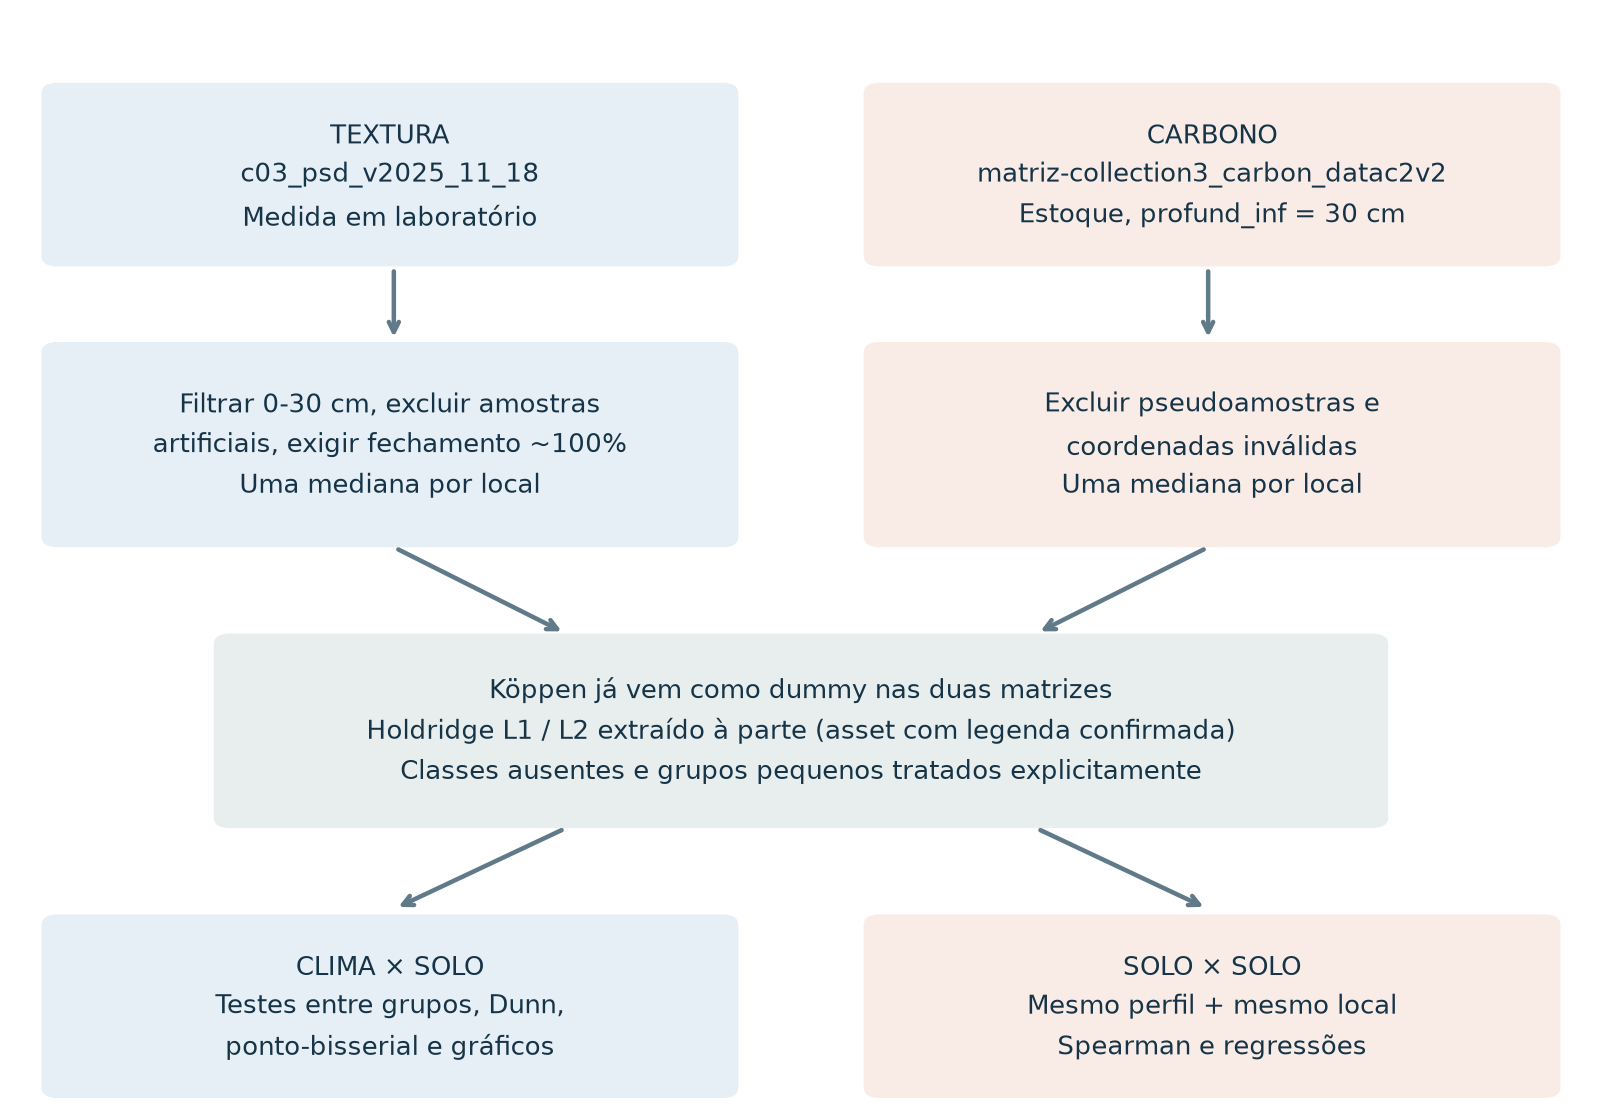

In [2]:
display(Image("resultados/figuras/rel_fluxo_metodologico.png"))

Figura 1. Fluxo efetivamente executado.

## 2. Preparação da amostra e critérios de teste

Textura: filtrada em `profundidade ≤ 30 cm` (a matriz não tem intervalos de horizonte — é uma leitura por ponto, em uma profundidade), convertida de g/kg para %, com o fechamento areia+silte+argila conferido (tolerância de 1 ponto percentual). SOC: `soc_stock_g_m2`, com `PSEUDO_index = 1` excluído. Nas duas matrizes, coordenadas repetidas (o mesmo ponto aparece uma vez por ano, em até ~40 linhas) foram agregadas pela mediana por ponto — mantê-las infla o n artificialmente e viola a independência que os testes exigem.

| Critério | Textura | SOC |
| --- | ---: | ---: |
| Linhas brutas | 59.682 | 22.532 |
| Amostras artificiais excluídas (`clay-copy-`/pseudo) | 12.958 | 21 (`PSEUDO_index`) |
| Fora de 0-30 cm ou com fração inválida | 24.727 | 0 |
| Agregados por ponto sem fechar ~100% | 291 | — |
| Pontos únicos válidos | 12.062 | 12.286 |

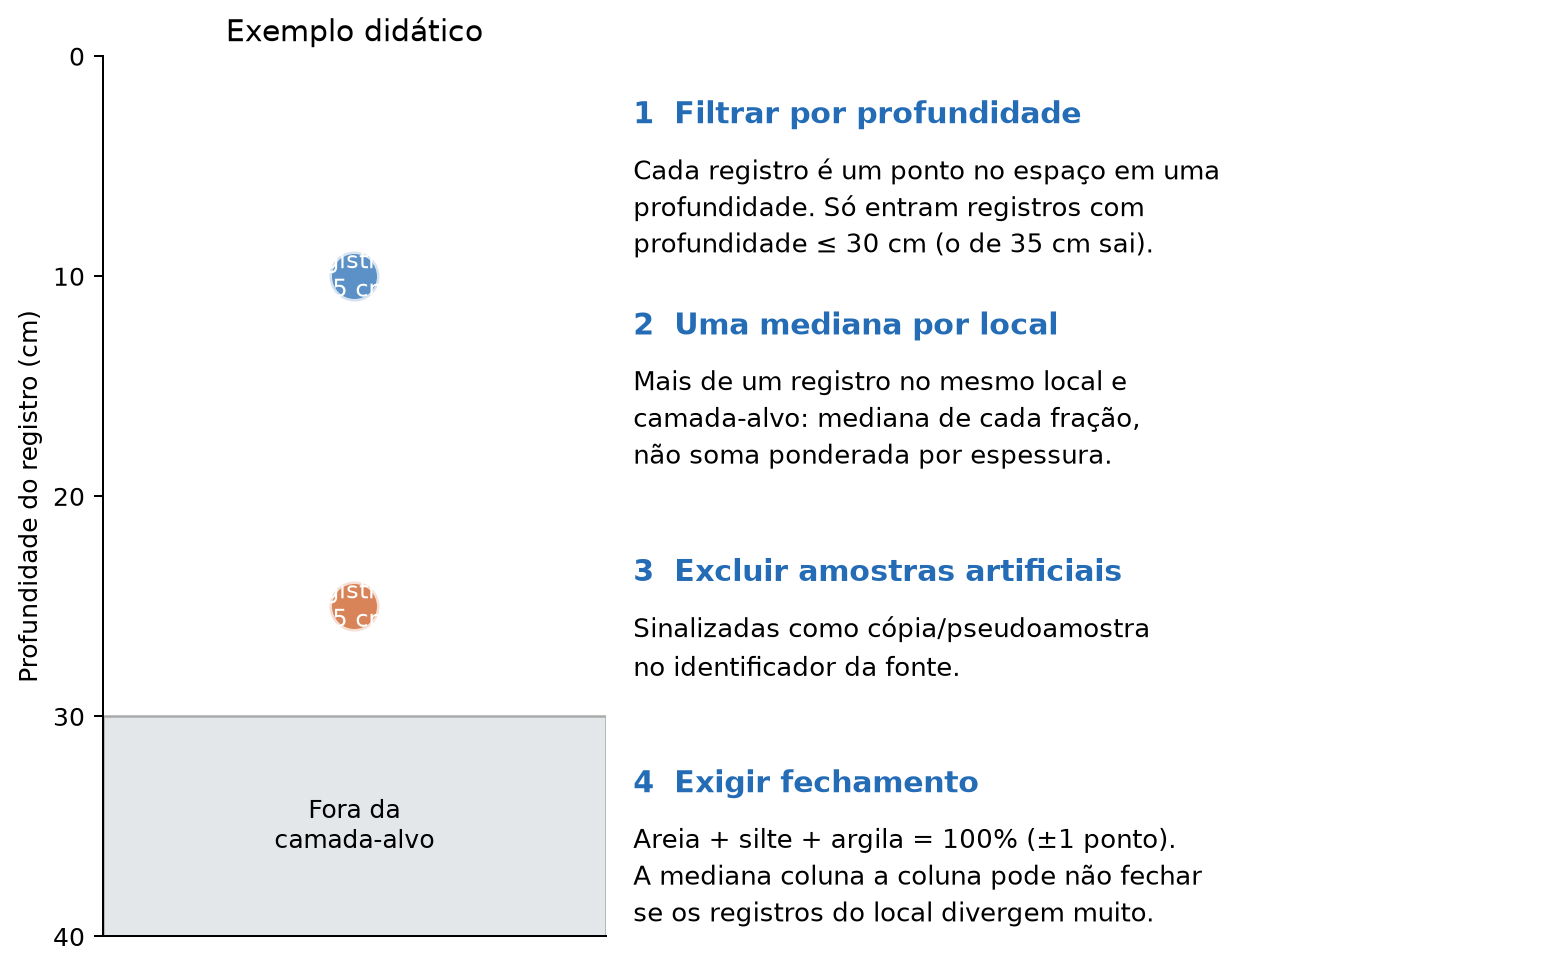

In [3]:
display(Image("resultados/figuras/rel_integracao_030.png"))

Figura 2. Um mesmo local pode ter mais de um registro de laboratório dentro de 0-30 cm; a mediana por fração, coluna a coluna, às vezes não fecha 100% — esses 291 locais foram excluídos.

> Classes com menos de 30 observações válidas são excluídas dos testes, Dunn, ponto-bisserial e boxplots. O mesmo subconjunto alimenta todos esses cálculos para uma dada resposta/nível.

## 3. Etapa 1 — textura × classes climáticas

Estatística descritiva, Kruskal-Wallis com ANOVA/Welch complementares, post-hoc de Dunn-Holm, ponto-bisserial e η²H = max[0, (H-k+1)/(n-k)], para cada fração e nível climático.

| Fração | Köppen L1 | Köppen L2 | Köppen L3 | Holdridge L1 | Holdridge L2 |
| --- | --- | --- | --- | --- | --- |
| Areia | 0,085 | 0,094 | 0,149 | 0,077 | 0,090 |
| Silte | 0,121 | 0,186 | 0,112 | 0,131 | 0,179 |
| Argila | 0,033 | 0,063 | 0,171 | 0,018 | 0,042 |

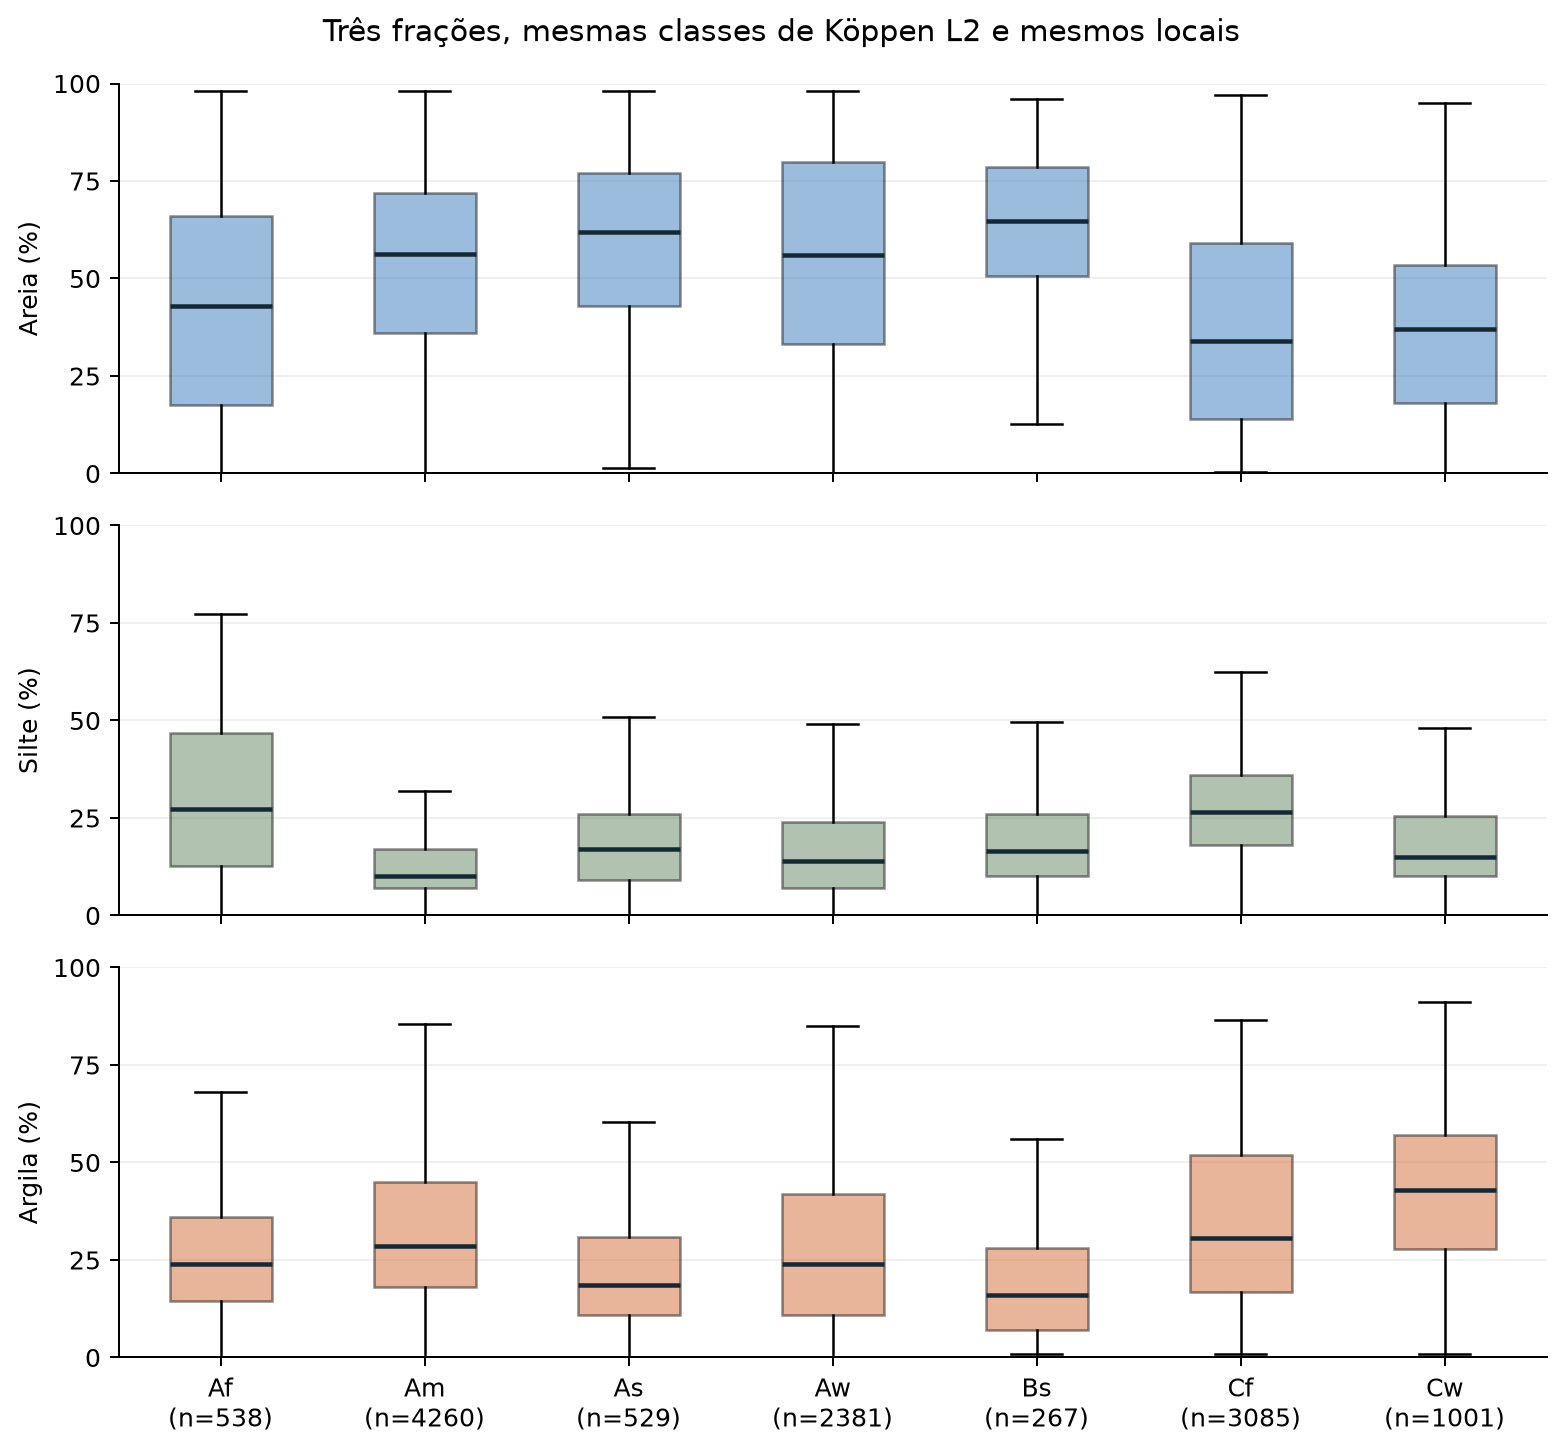

In [4]:
display(Image("resultados/figuras/rel_textura_tres_fracoes.png"))

Figura 3. As três frações, mesmas classes de Köppen L2 e mesmos locais. Caixas: metade central; linha: mediana; bigodes: até 1,5 IQR.

> Os 20 testes globais desta análise têm p ajustado por Holm < 0,05. Os valores são medidas de laboratório, não a covariável de textura modelada (que usaria clima como entrada e tornaria o cruzamento parcialmente circular).

## 4. Etapa 1, Holdridge — e a direção dos efeitos

Com a legenda confirmada, `HLZ_L1` tem só 2 das 7 zonas térmicas efetivamente presentes na amostra (Tropical e Subtropical — coerente com o clima do Brasil), e `HLZ_L2` tem 8 das 38.

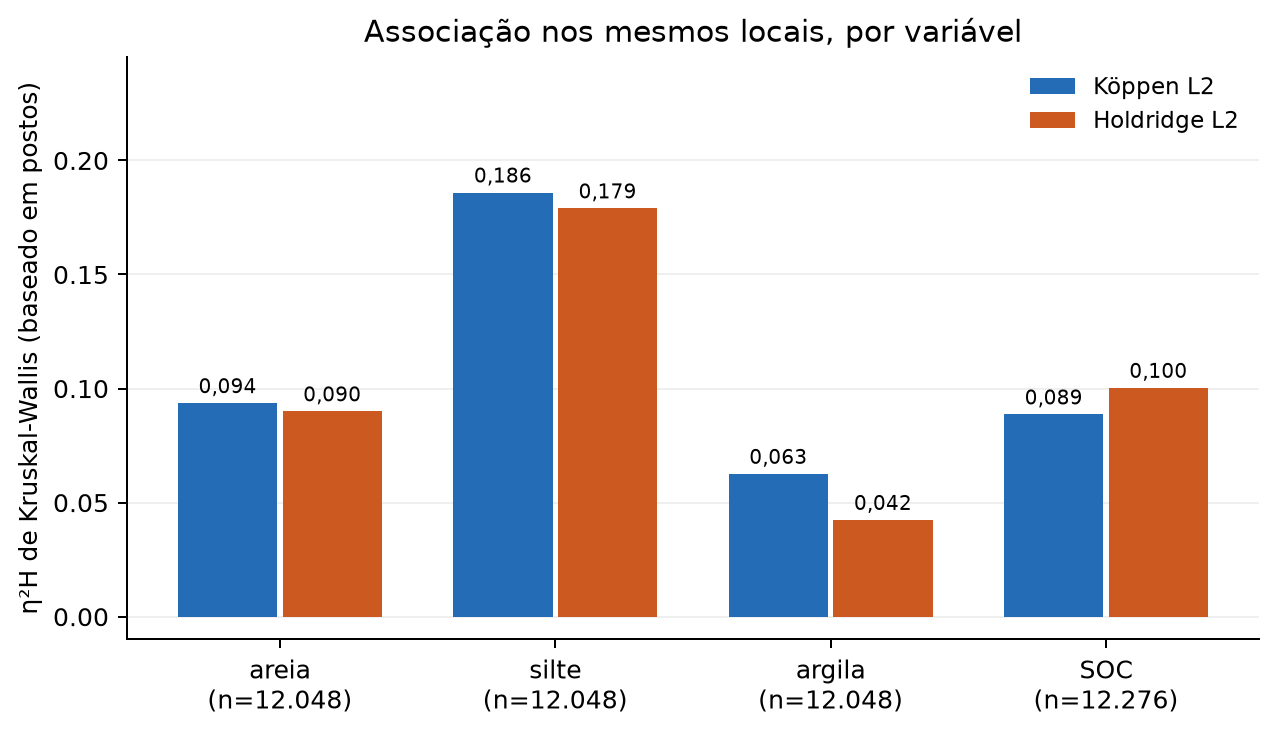

In [5]:
display(Image("resultados/figuras/rel_comparacao_clima.png"))

Figura 4. Associação nos mesmos locais, Köppen L2 vs. Holdridge L2, por variável.

| Fração | Classe vs. demais | r ponto-bisserial | n total |
| --- | --- | ---: | ---: |
| silte | Köppen L2 Cf | 0,323 | 12.061 |
| silte | Köppen L2 Am | -0,289 | 12.061 |
| areia | Köppen L2 Cf | -0,234 | 12.061 |
| argila | Köppen L2 Cw | 0,165 | 12.061 |
| silte | Köppen L2 Af | 0,160 | 12.061 |

> r positivo indica que a classe tem valores maiores que o restante das classes elegíveis; negativo, menores. Não é um ranking causal — é uma síntese descritiva, com todas as classes e p ajustados no CSV consolidado.

## 5. Etapa 2 — carbono orgânico × classes climáticas

Mesma bateria de testes, sobre `soc_stock_g_m2`. Esta matriz não tem a variável qmap — só o estoque original é analisado.

| Nível | n | Classes | η²H |
| --- | ---: | ---: | ---: |
| Köppen L1 | 12.286 | 3 | 0,076 |
| Köppen L2 | 12.285 | 7 | 0,089 |
| Köppen L3 | 5.000 | 5 | 0,183 |
| Holdridge L1 | 12.282 | 2 | 0,071 |
| Holdridge L2 | 12.277 | 8 | 0,100 |

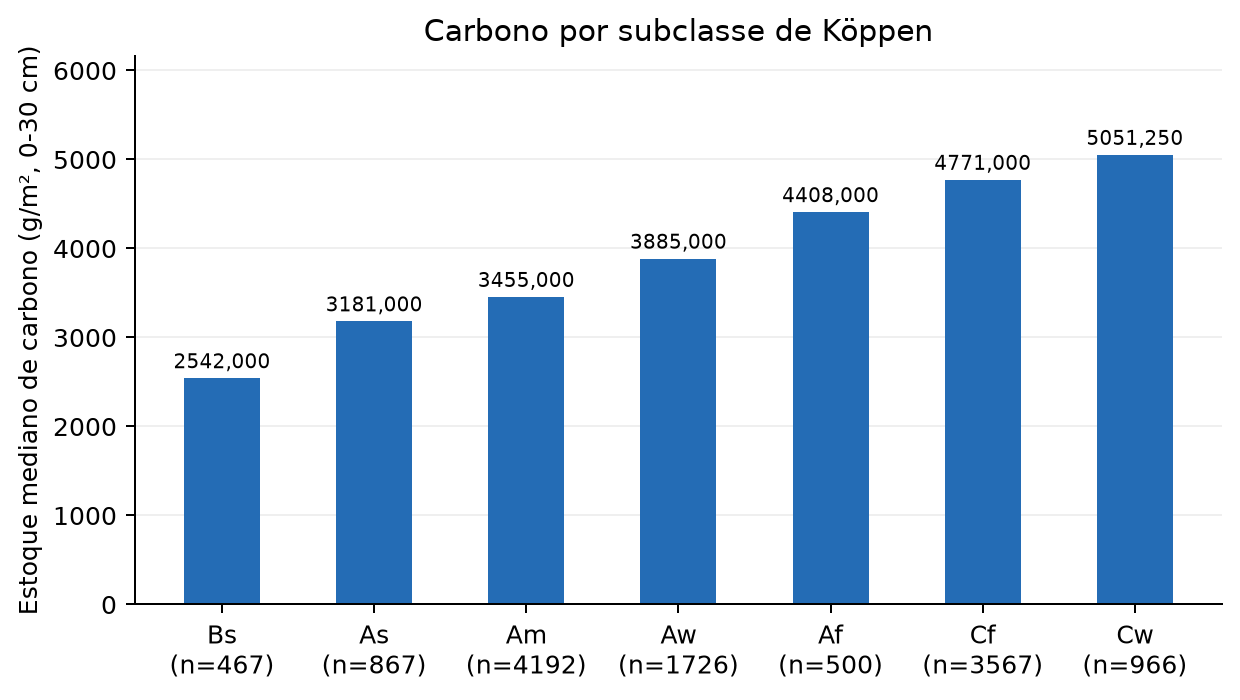

In [6]:
display(Image("resultados/figuras/rel_soc_koppen.png"))

Figura 5. Estoque mediano de SOC por subclasse de Köppen.

## 6. Etapa 2, Holdridge — o gradiente de carbono

Com a legenda confirmada, fica claro que não existem zonas frias na amostra brasileira — só Tropical e Subtropical aparecem, com uma diferença moderada entre elas (não a ordem de grandeza que um gradiente latitudinal completo, de zonas polares a tropicais, sugeriria).

| Zona de Holdridge (L1) | n | Mediana (g/m²) | Média (g/m²) |
| --- | ---: | ---: | ---: |
| Subtropical_Zone | 4.057 | 4.985 | 5.952 |
| Tropical_Zone | 8.225 | 3.549 | 4.684 |

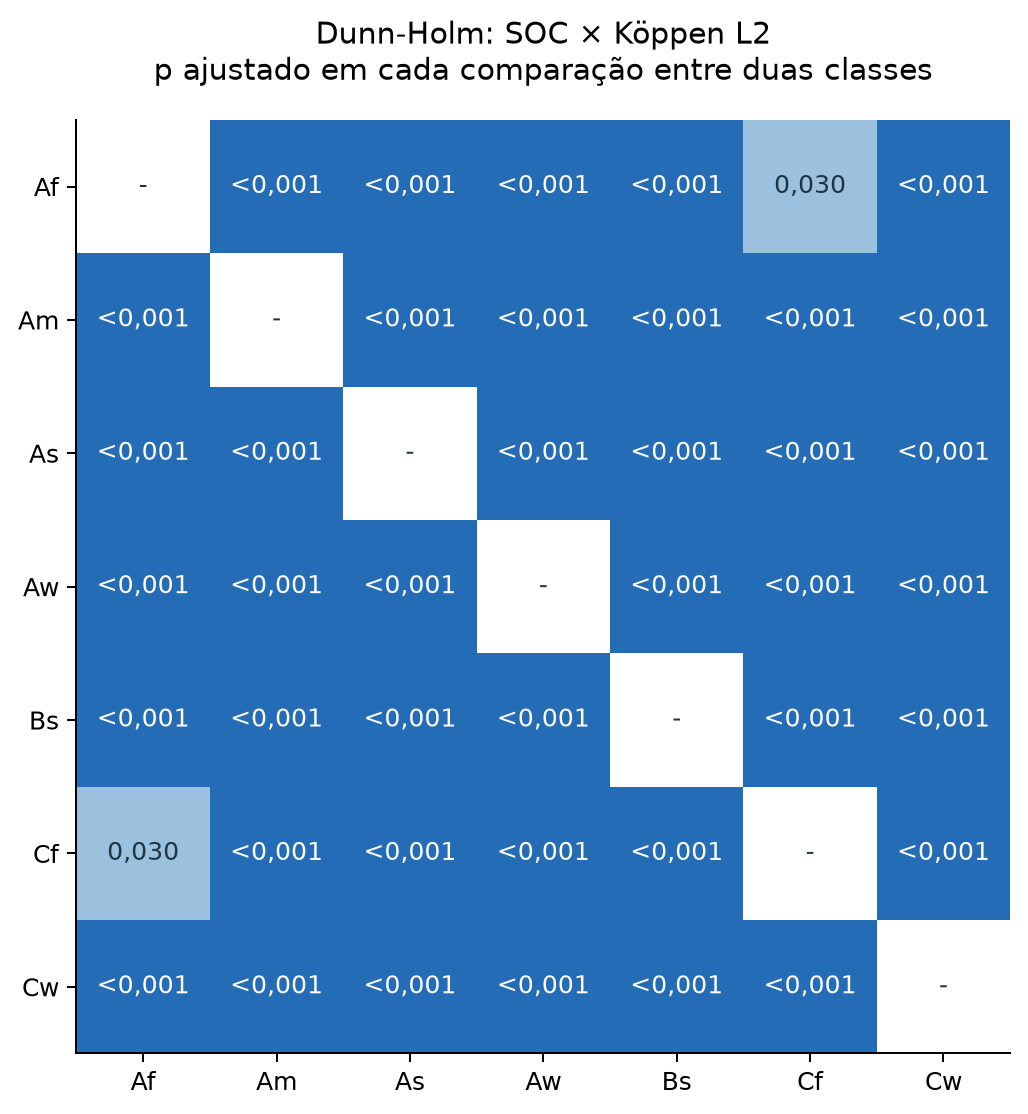

In [7]:
display(Image("resultados/figuras/rel_dunn_soc_koppen.png"))

Figura 6. Pós-teste de Dunn-Holm completo (SOC × Köppen L2) — exemplo de como interpretar a matriz de comparações entre pares de classes.

> O par Subtropical×Tropical de Holdridge L1 difere com p < 0,001 no post-hoc de Dunn (é o único par possível em L1, já que só há duas classes elegíveis). A diferença é real, mas moderada — cerca de 1,4× na mediana, não um gradiente amplo entre zonas térmicas distantes.

## 7. Carbono e textura no mesmo local

Correlação de Spearman entre `soc_stock_g_m2` e cada fração, nos 9.792 locais presentes nas duas matrizes.

| Par | ρ de Spearman | n |
| --- | ---: | ---: |
| SOC x areia | -0,499 | 9.792 |
| SOC x silte | 0,384 | 9.792 |
| SOC x argila | 0,437 | 9.792 |

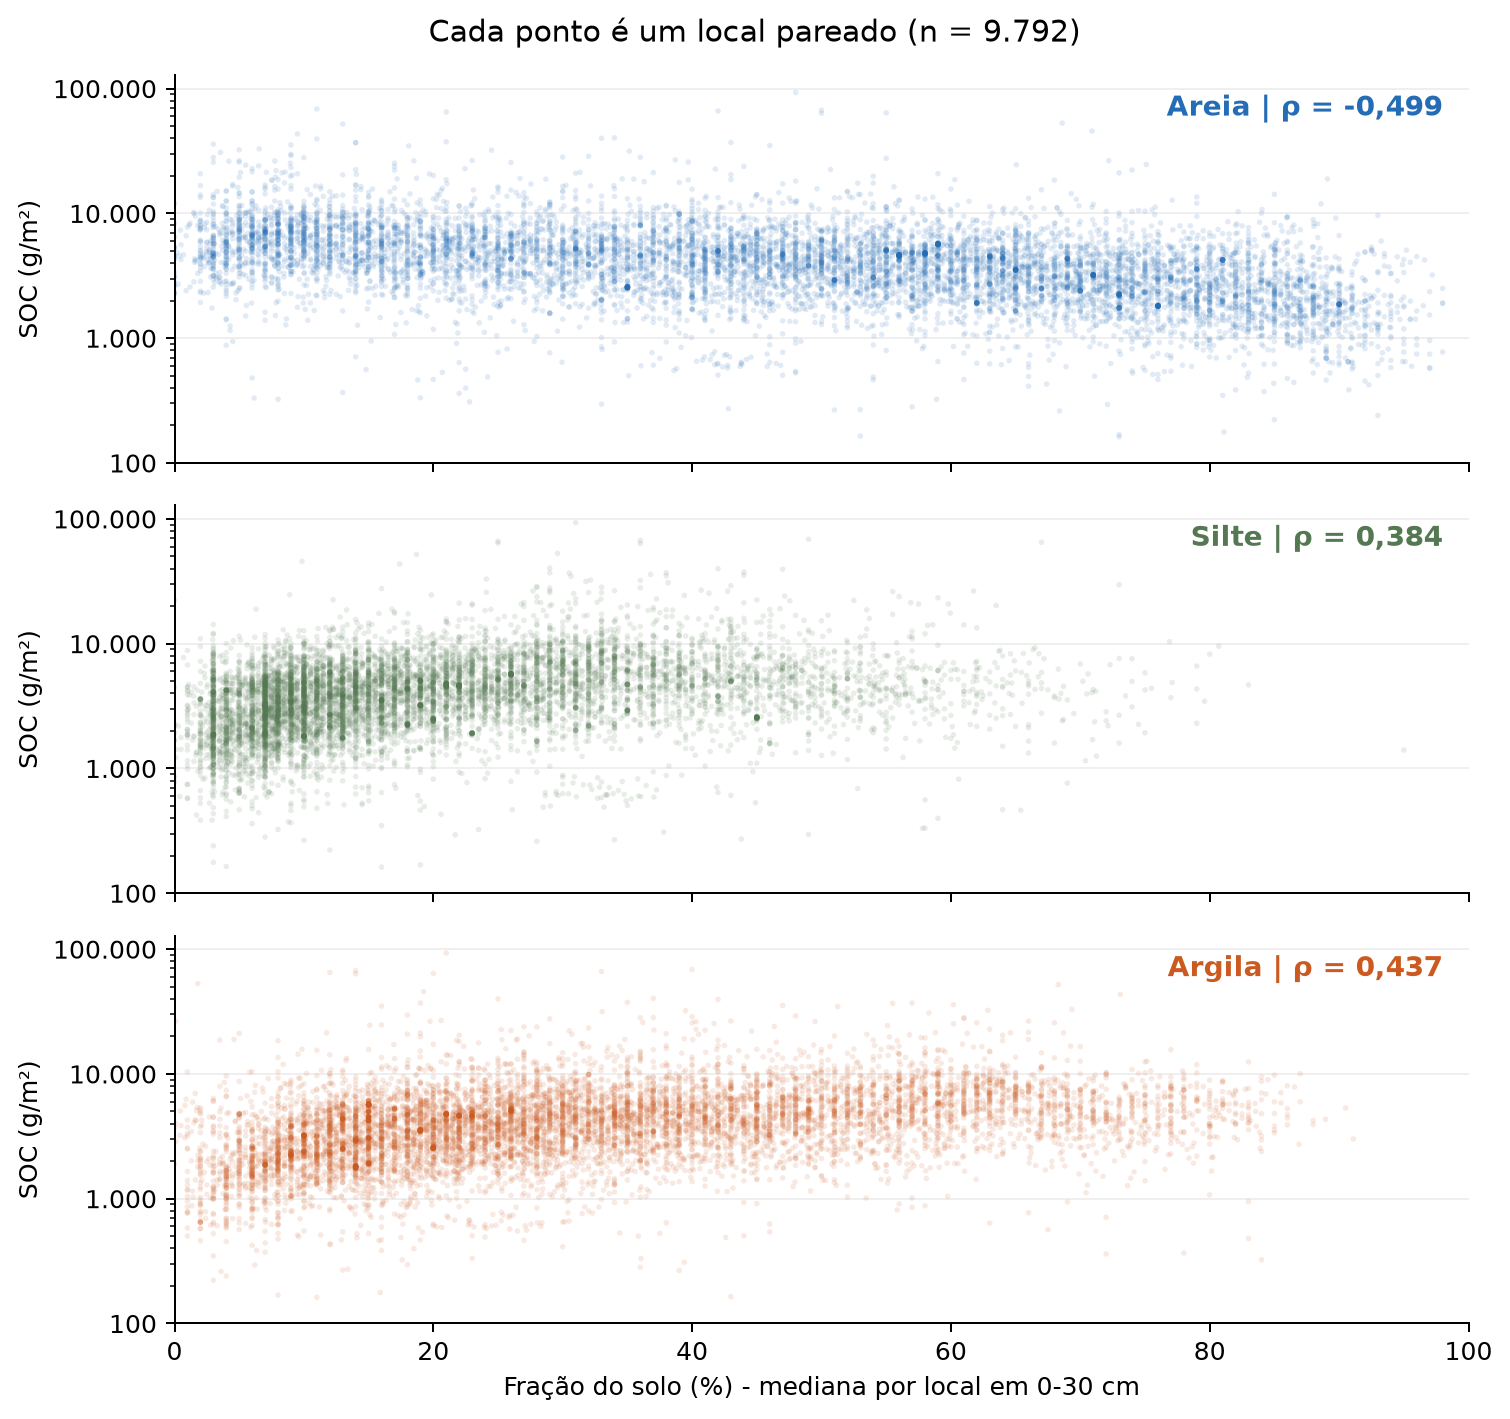

In [8]:
display(Image("resultados/figuras/rel_soc_textura_dispersao.png"))

Figura 7. Distribuições observadas, sem linha causal ajustada. Solos mais argilosos retêm mais carbono; solos arenosos, menos — compatível com o mecanismo de estabilização de matéria orgânica na matriz mineral (Cotrufo et al., 2013).

> Spearman capta associação monotônica, não linearidade nem causalidade. Como textura e carbono variam juntos no espaço, parte da correlação pode refletir fatores ambientais comuns aos dois.

## 8. Regressões: associação condicional

Cinco modelos aninhados sobre o logaritmo do estoque de carbono, com a textura entrando por duas das três frações (areia e argila — silte é redundante, as três somam 100%), uma dummy climática de Köppen L2 omitida como referência.

| Modelo | Preditores | n | R² |
| --- | --- | ---: | ---: |
| M1 | clima (Köppen L2) | 9.791 | 0,085 |
| M2 | textura (areia, argila) | 9.791 | 0,225 |
| M3 | textura + clima | 9.791 | 0,248 |
| M4 | textura + clima + relevo | 9.791 | 0,270 |
| M5 | clima + relevo | 9.791 | 0,135 |

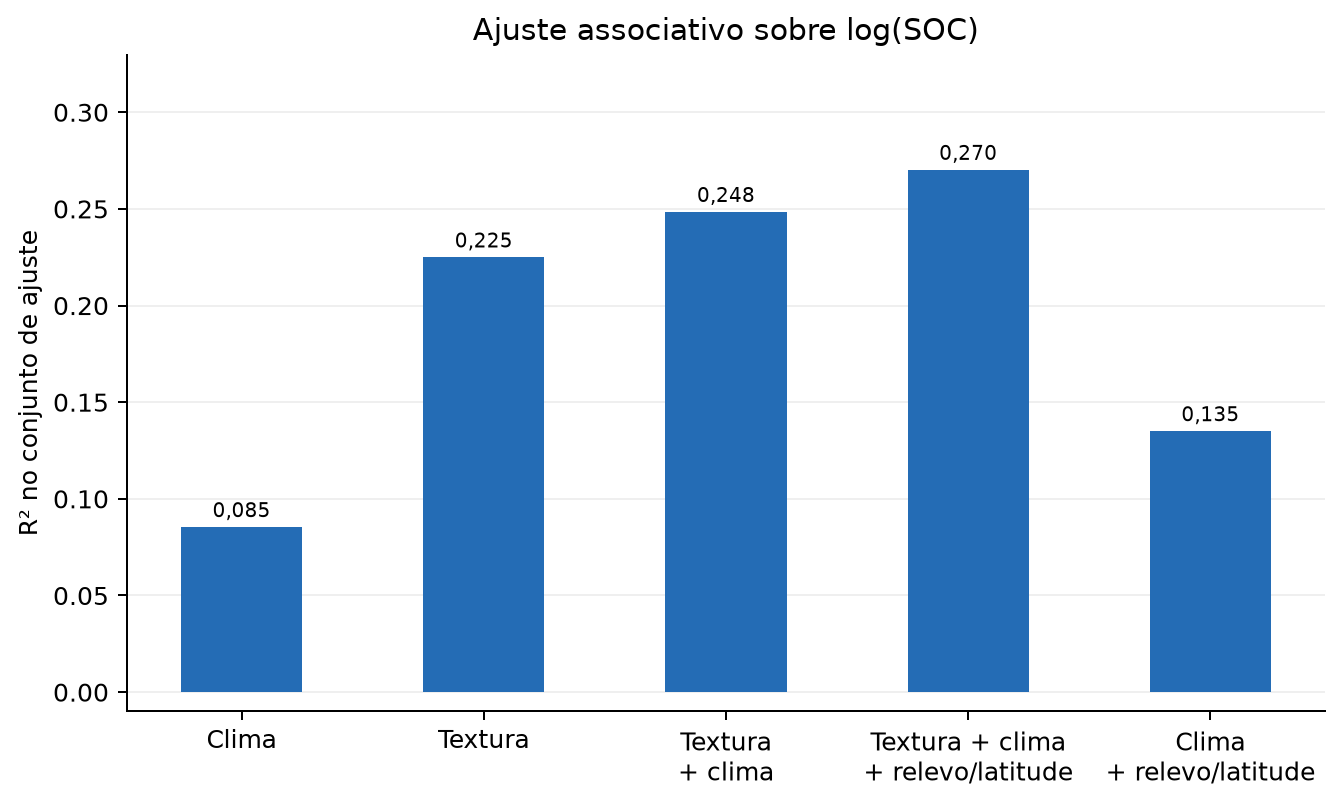

In [9]:
display(Image("resultados/figuras/rel_modelos_r2.png"))

Figura 8. R² no ajuste dos cinco modelos aninhados.

> Somar clima a um modelo que já conhece a textura acrescenta 0,024 de R² (0,248 - 0,225). Isso expressa associação condicional, não mediação causal: comparar R² de modelos encaixados não decompõe efeito direto e indireto.

## 9. Validação espacial e discriminação do clima

Random forest (RF) combina árvores de decisão para captar relações não lineares. A comparação com OLS usa exatamente os mesmos preditores e as mesmas dobras — cinco dobras aleatórias e blocos espaciais de 1°, 2° e 5° (GroupKFold, sem buffer entre blocos).

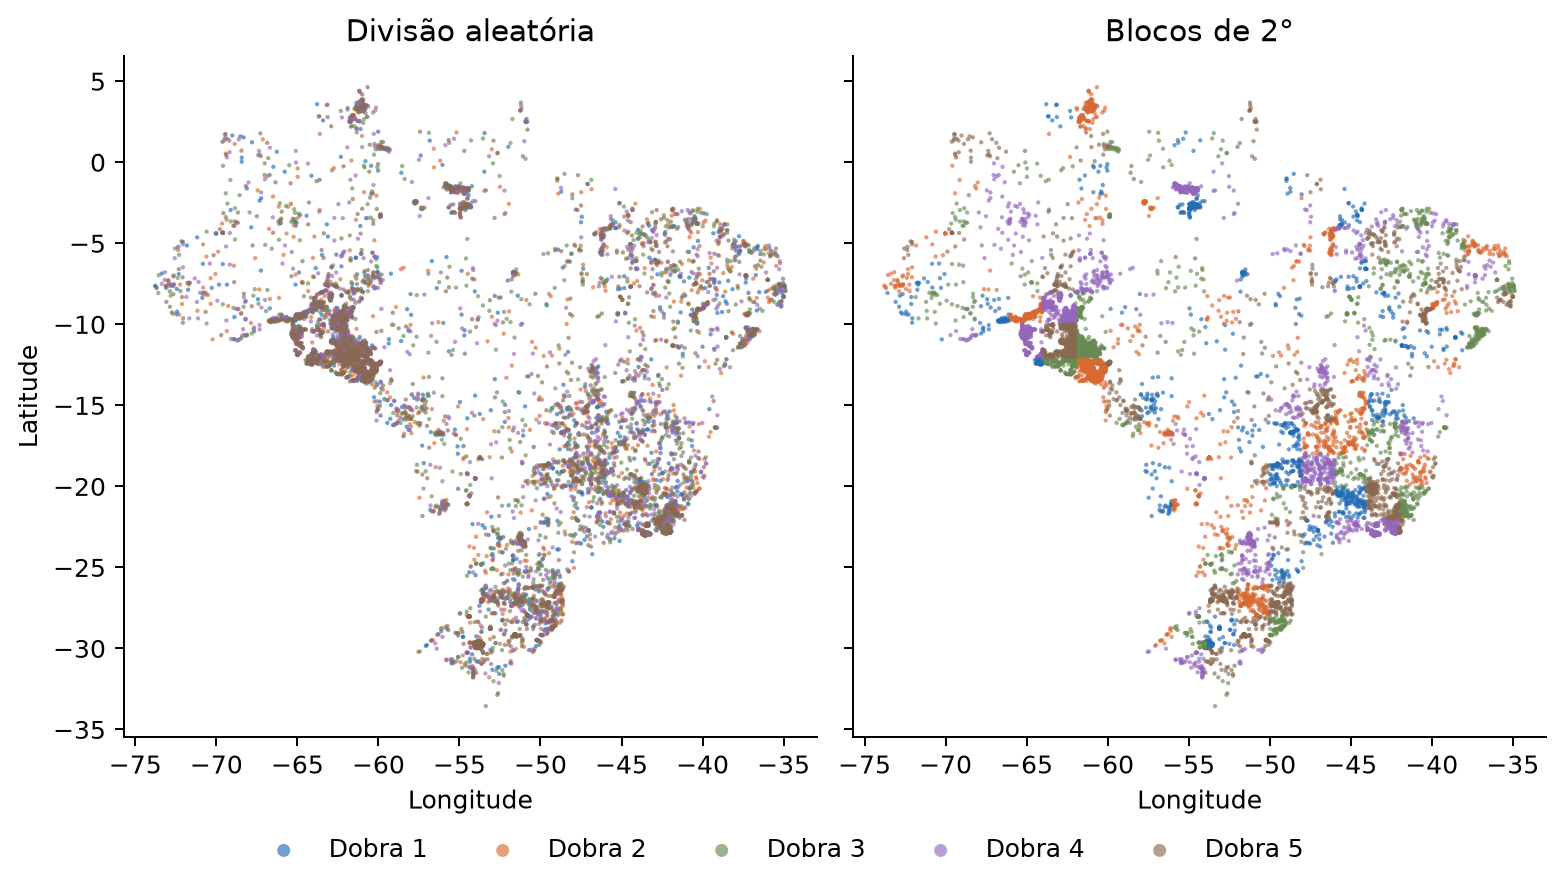

In [10]:
display(Image("resultados/figuras/rel_dobras_espaciais.png"))

Figura 9. Partições realmente usadas. Uma cor identifica uma dobra de teste.

| Esquema | OLS (R² OOF) | Random Forest (R² OOF) |
| --- | ---: | ---: |
| Aleatória | 0,269 | 0,412 |
| Espacial 1° | 0,247 | 0,286 |
| Espacial 2° | 0,254 | 0,262 |
| Espacial 5° | 0,252 | 0,248 |

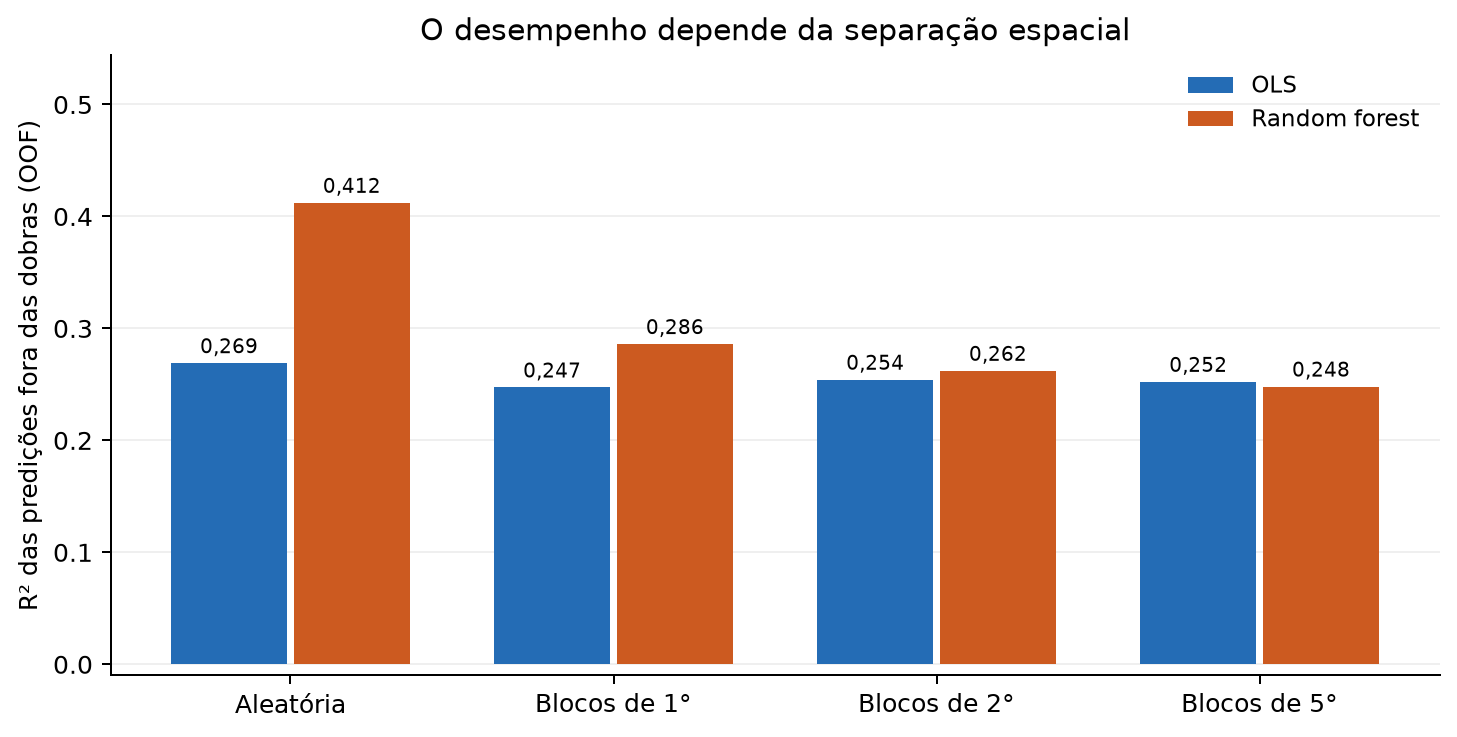

In [11]:
display(Image("resultados/figuras/rel_validacao_espacial.png"))

Figura 10. O desempenho do random forest depende do desenho de validação.

> A vantagem do random forest sobre OLS cai de +0,14 na divisão aleatória para virtualmente zero nos blocos espaciais de 5° — pontos vizinhos no espaço se parecem, então a divisão aleatória mede otimista.

Regressão logística multinomial, prevendo a subclasse de Köppen (L2) a partir de areia, argila e log(SOC): acurácia de 47,8% na divisão aleatória (baseline da classe majoritária: 34,4%) e 44,5% em blocos de 2° (baseline: 21,9% — blocos espaciais isolam classes geograficamente concentradas, o que muda o que "acertar a classe majoritária" significa). O solo não discrimina igualmente todas as classes climáticas.

## 10. Importância climática: Köppen vs. Holdridge, no mesmo modelo

As seções 3-6 comparam Köppen e Holdridge separadamente (um teste de cada vez). Aqui os dois entram **juntos** no mesmo random forest — o mesmo modelo M4 já usado na seção 8 (textura + clima + relevo, para SOC; clima + relevo, para as frações) — e mede-se a queda de R² ao embaralhar, em bloco, todas as dummies de um sistema climático de cada vez (Köppen L2 ou Holdridge L2), mantendo o resto do modelo intacto. Embaralhar uma dummy por vez criaria combinações inválidas (duas classes "ativas" ou nenhuma); embaralhar o bloco inteiro preserva a estrutura da variável categórica.

Avaliado fora da amostra nos mesmos blocos espaciais de 2° da seção 9 — CV aleatório infla a importância porque classes climáticas são espacialmente agrupadas (é exatamente o padrão que a seção 9 já mostra: R² do random forest cai de 0,41 no aleatório para ~0,25 em blocos de 5°).

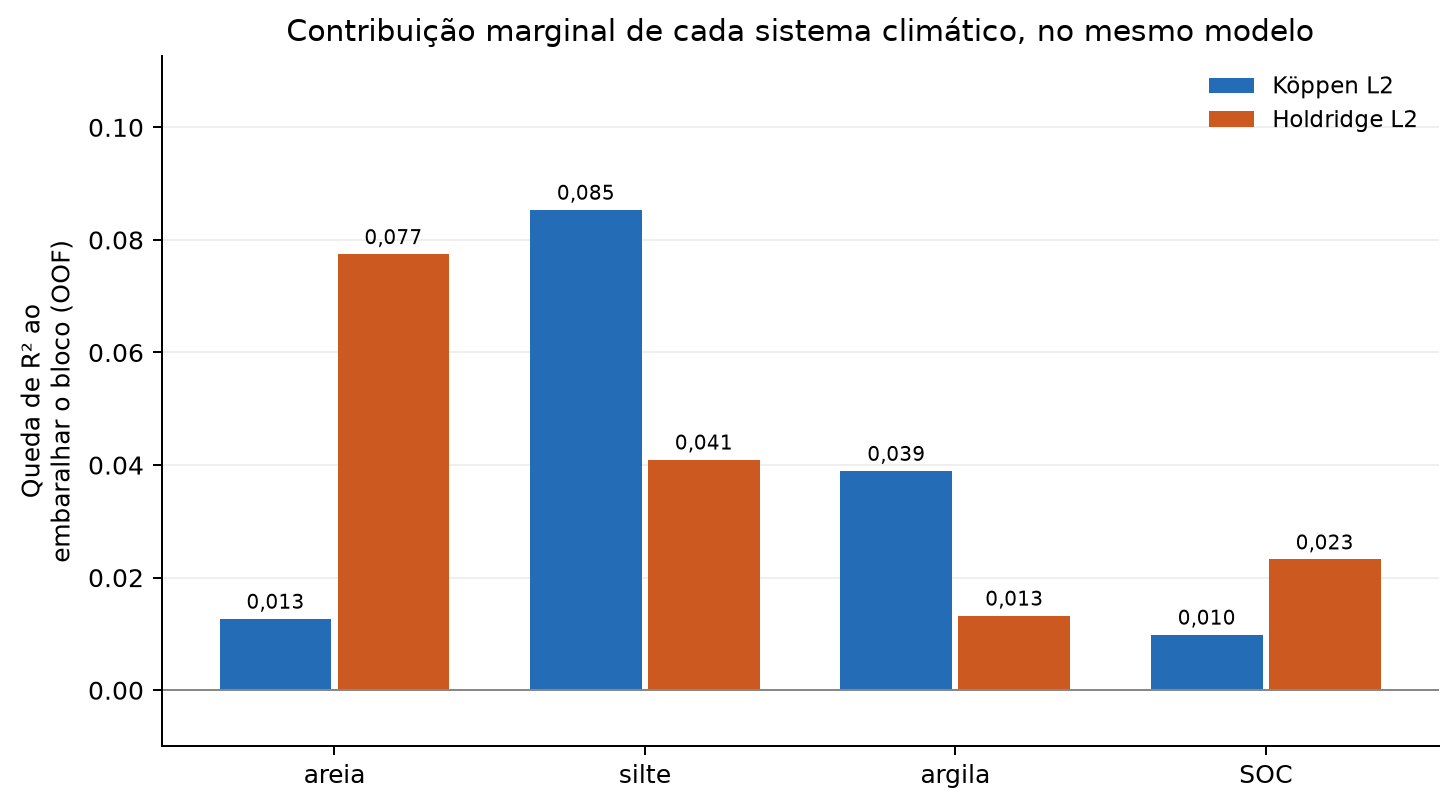

In [12]:
display(Image("resultados/figuras/rel_importancia_climatica.png"))

Figura 11. Contribuição marginal de cada sistema, com o outro já presente no modelo — por isso os valores são menores que o η²H isolado das seções 3-6: aqui já se descontou o que os dois sistemas explicam em comum.

In [13]:
importancia_climatica = pd.read_csv(TABELAS / "importancia_climatica.csv")
importancia_climatica.round(4)

,variavel_pt,bloco,queda_r2_media,queda_r2_dp,r2_base_medio,n_folds,queda_pct_do_r2
0,SOC,Holdridge L2,0.0232,0.0122,0.2629,5,8.8399
1,SOC,Köppen L2,0.0099,0.0100,0.2629,5,3.7539
2,SOC,Relevo,0.0983,0.0315,0.2629,5,37.3990
3,SOC,Textura,0.4310,0.0663,0.2629,5,163.9411
4,areia,Holdridge L2,0.0775,0.0478,0.1171,5,66.1556
5,areia,Köppen L2,0.0127,0.0281,0.1171,5,10.8412
6,areia,Relevo,0.4749,0.1861,0.1171,5,405.5264
7,argila,Holdridge L2,0.0132,0.0295,0.1073,5,12.3471
8,argila,Köppen L2,0.0390,0.0131,0.1073,5,36.3154
9,argila,Relevo,0.3480,0.1257,0.1073,5,324.3400


Não há um vencedor único entre os dois sistemas — a resposta muda por variável: Holdridge L2 contribui mais para areia (0,077 vs. 0,013) e SOC (0,023 vs. 0,010); Köppen L2 contribui mais para silte (0,085 vs. 0,041) e argila (0,039 vs. 0,013). Em todas as quatro respostas, **relevo (elevação + latitude) supera os dois sistemas climáticos combinados** — geografia contínua, de granularidade mais fina, carrega mais informação que qualquer classificação climática categórica, uma vez que os dois sistemas já competem no mesmo modelo.

> O desvio-padrão entre as cinco dobras espaciais é grande em relação à média (ex.: areia, Holdridge L2: 0,077 ± 0,048) — a divisão de blocos de 2° tem poucos blocos e cobertura geográfica desigual, então essa comparação é indicativa, não uma estimativa de alta precisão. `resultados/tabelas/importancia_climatica_folds.csv` tem o detalhe por dobra.

## 11. Síntese, atendimento ao escopo e limites

1. Há associação solo-clima nos pontos elegíveis: os 20 testes globais são significativos após Holm. Isso não demonstra causa nem representatividade nacional.

2. A textura contém informação associada ao SOC. Acrescentar clima à textura aumenta o R² do ajuste em 0,024 em log(SOC). Essa diferença não separa efeitos causais diretos e mediados.

3. A predição é sensível à separação espacial. A vantagem do random forest na divisão aleatória praticamente desaparece com blocos maiores.

| Pedido / extensão | Situação |
| --- | --- |
| Textura e SOC, cinco níveis climáticos | Calculados; Holdridge com legenda confirmada |
| Descritivas, KW, ANOVA/Welch, Dunn | Tabelas completas consolidadas |
| Ponto-bisserial, Spearman e boxplots | Calculados; amostras e unidades identificadas |
| Matriz `trainingFinal` indicada no escopo original | Bloqueada mesmo com acesso liberado às demais; usada a matriz de carbono alternativa |
| Legenda de Holdridge | Resolvida via asset documentado (`holdridge_lifezones_chelsa-v2026`) |
| Regressões (extensão opcional) | OLS, RF e logística, com validação aleatória e espacial |
| Importância climática por variável (extensão opcional) | Köppen vs. Holdridge, mesmo modelo, permutação em bloco (seção 10) |
| Modelos mistos / GWR (extensão opcional) | Não ajustados |
| Notebook | Resultados, método e limitações documentados |

> Limites principais: levantamentos não aleatórios, seleção por completude do local, possível diferença de datas de coleta, fechamento das frações, autocorrelação espacial, e SOC sem a variável qmap (não existe nesta matriz). O trabalho sustenta associações exploratórias; não identifica mediação causal.

## 12. Fontes, rastreabilidade e material de apoio

Assets do Earth Engine usados nesta análise (detalhe completo em `docs/assets.md`):

| Asset | Uso neste trabalho |
| --- | --- |
| `matriz-collection3_carbon_datac2v2` | SOC: estoque de carbono orgânico por ponto |
| `c03_psd_v2025_11_18` | Textura: areia/silte/argila medidas em laboratório |
| `IPEF_2013_KOPPEN_100M_2025` (koppen_l1/l2/l3) | Classificação de Köppen, já embutida como dummy nas duas matrizes acima |
| `holdridge_lifezones_chelsa-v2026` | Holdridge (HLZ_L1/L2), banda `zone38_id`, legenda documentada no próprio asset |

Código de contexto do produto MapBiomas Solo: https://github.com/mapbiomas/brazil-soil/tree/main/soil_30m_landsat/collection_03beta. A legenda do mapa-base Köppen está no script `covariate_export/IPEF_2013_KOPPEN_100M` desse repositório.

Referências metodológicas: SciPy, Kruskal-Wallis, https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html; Imai, Keele e Yamamoto (2010), mediação causal, https://doi.org/10.1214/10-STS321; Pohjankukka et al., validação espacial, https://arxiv.org/abs/2005.14263; Cotrufo et al. (2013), estabilização da matéria orgânica na matriz mineral, https://doi.org/10.1111/gcb.12113; Breiman (2001), random forest, https://doi.org/10.1023/A:1010933404324.

| Material entregue | Como consultar |
| --- | --- |
| README.md | Ordem de leitura e estrutura do repositório |
| solo_clima_consolidado.ipynb | Versão navegável, executada e com tabelas consolidadas |
| resultados/tabelas/ | 20 testes globais, descritivas, pares Dunn, correlações, modelos e importância climática (14 CSVs) |
| resultados/fontes/ | Versões, hashes das fontes, legenda de Holdridge e amostras |
| codigo/ e docs/reproducao.md | Código científico e instruções para recalcular (exige acesso GEE liberado) |

> Os CSVs mantêm precisão integral; o texto e os gráficos arredondam para leitura. P numérico igual a zero pode ser subfluxo de ponto flutuante. Dados brutos e resultados intermediários não integram a entrega pública.

## Painéis complementares: todos os níveis climáticos

Cada painel reúne as quatro respostas (areia, silte, argila, SOC). As classes são as bandas dos assets, com a legenda de Holdridge confirmada no asset `holdridge_lifezones_chelsa-v2026`. Nos painéis, SOC foi convertido de g/m² para t/ha (divisão por 100) e usa escala simétrica-log com trecho linear até 10 t/ha. As tabelas mantêm a unidade original. Os arquivos PNG em `resultados/figuras/` permitem ampliar os rótulos.

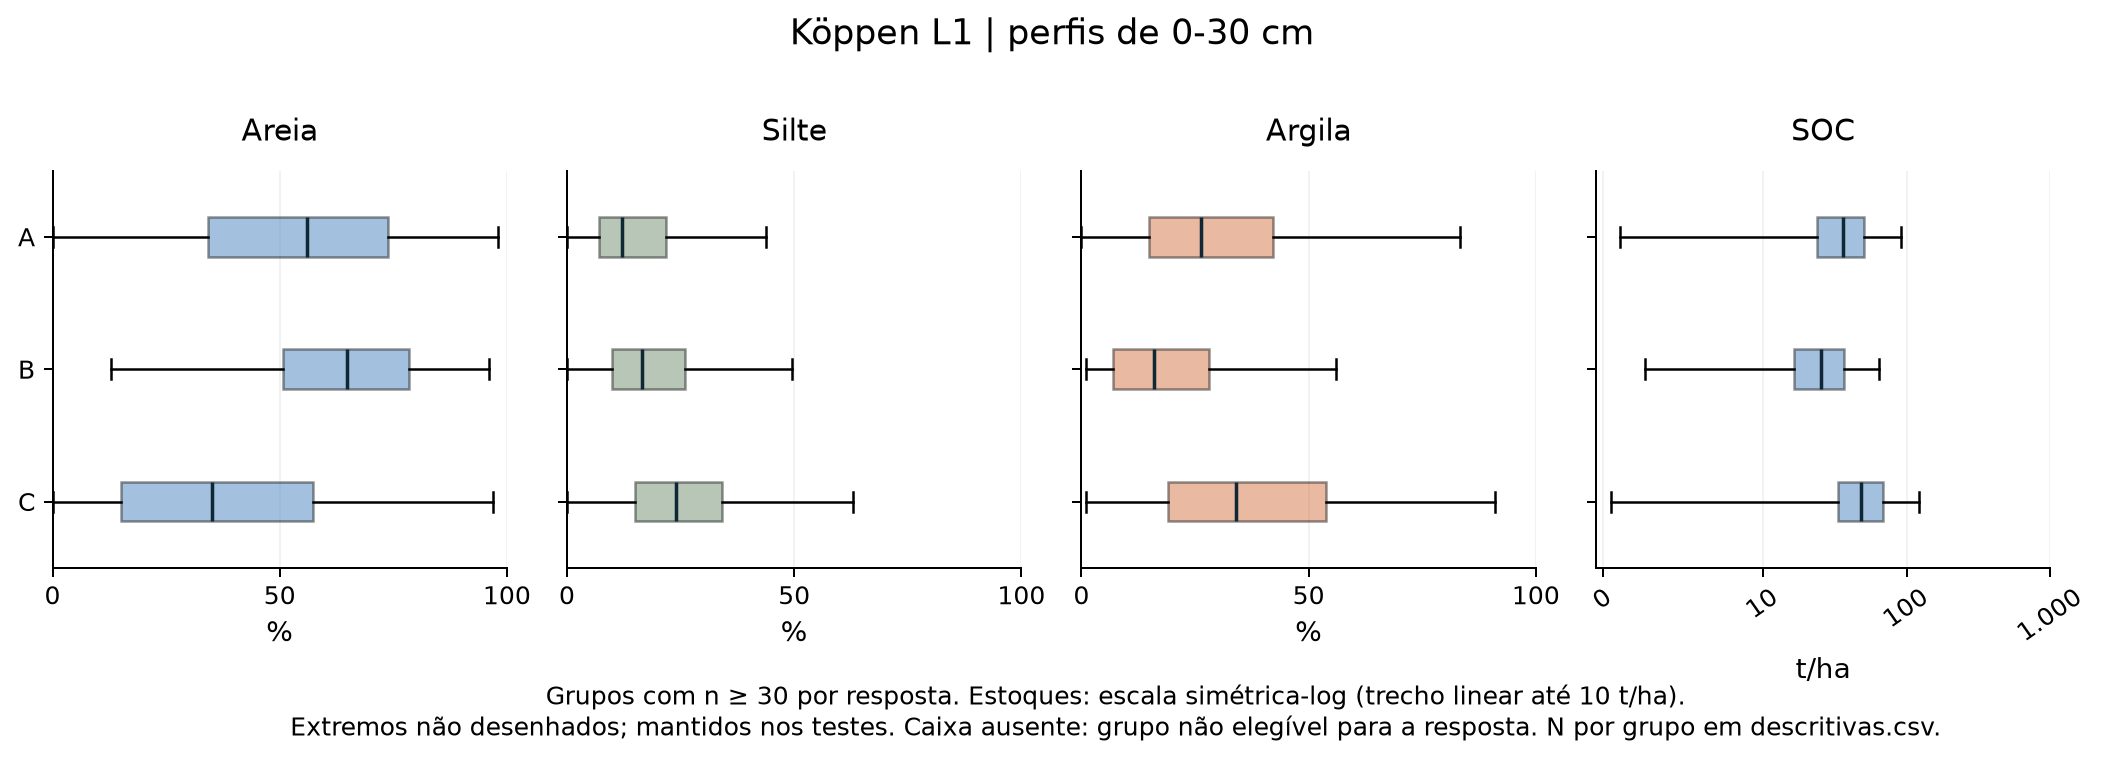

In [14]:
display(Image("resultados/figuras/painel_koppen_l1.png"))

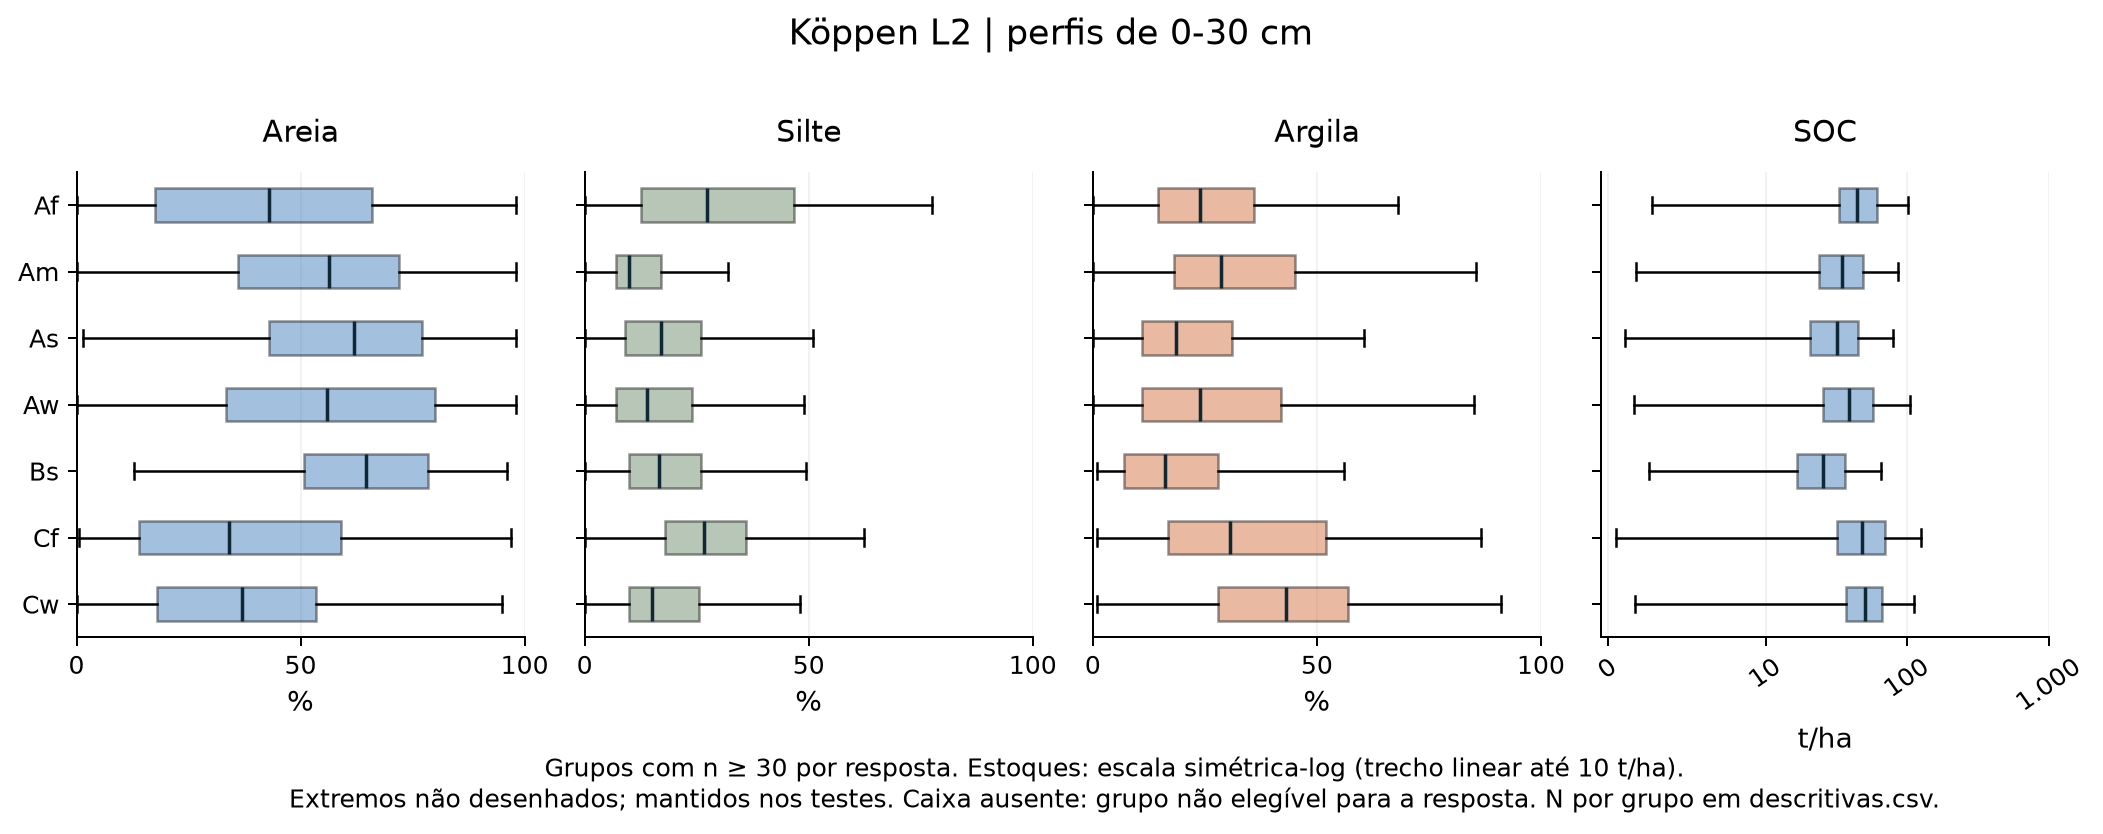

In [15]:
display(Image("resultados/figuras/painel_koppen_l2.png"))

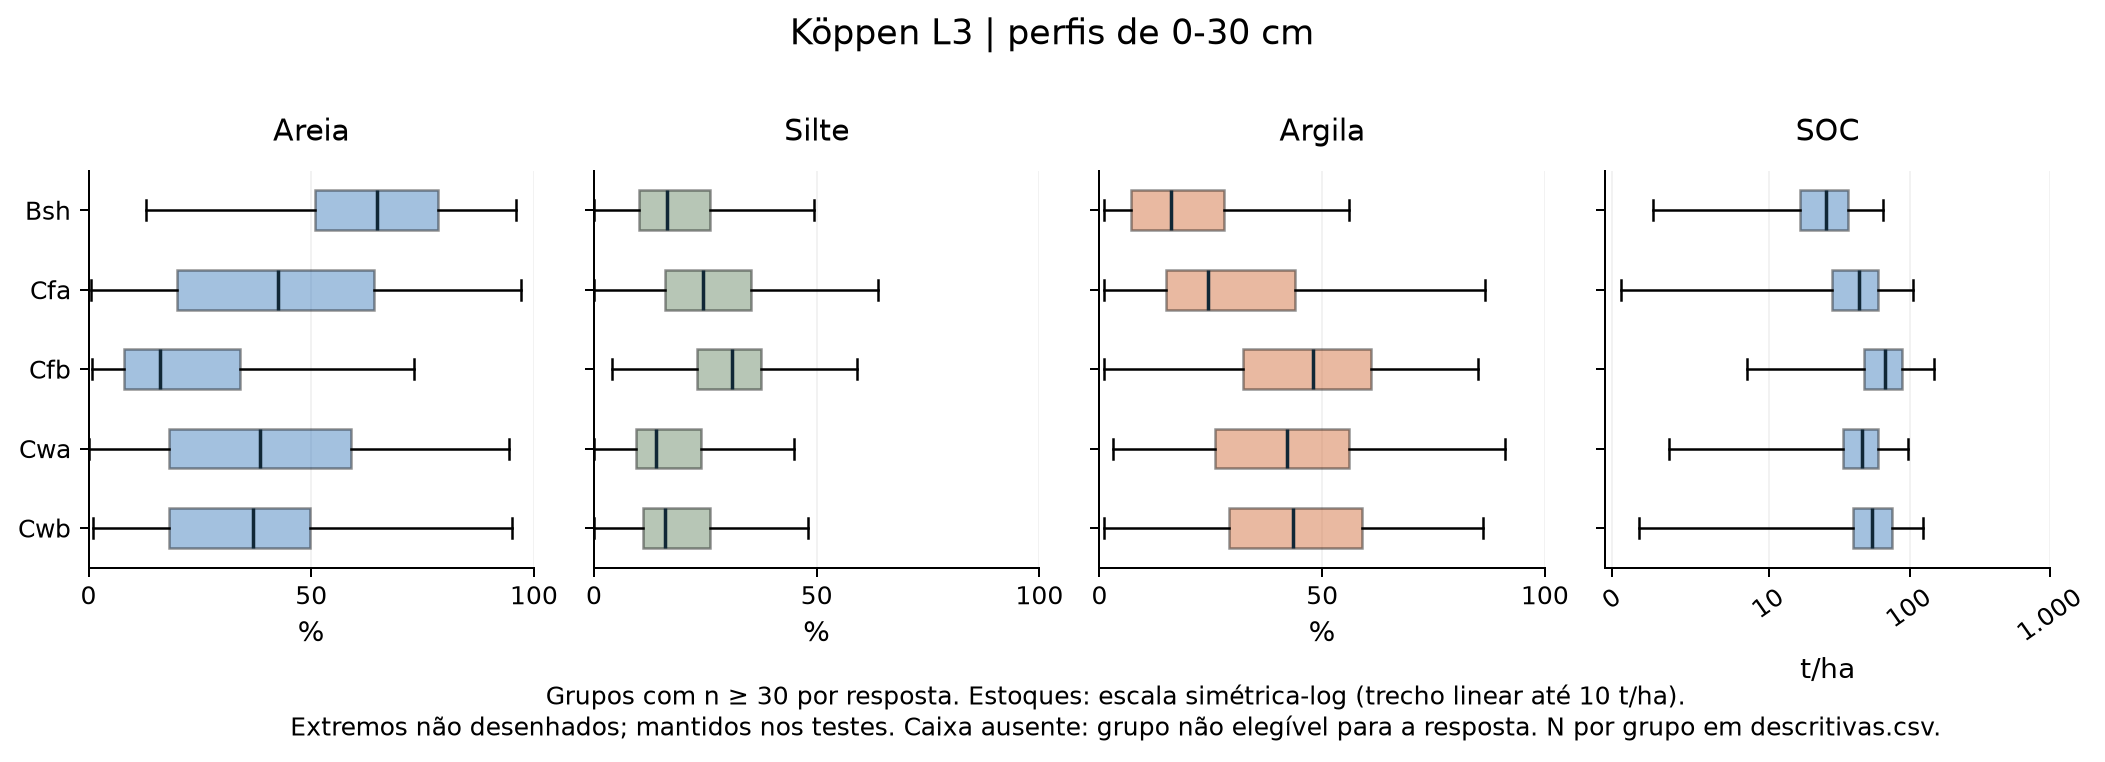

In [16]:
display(Image("resultados/figuras/painel_koppen_l3.png"))

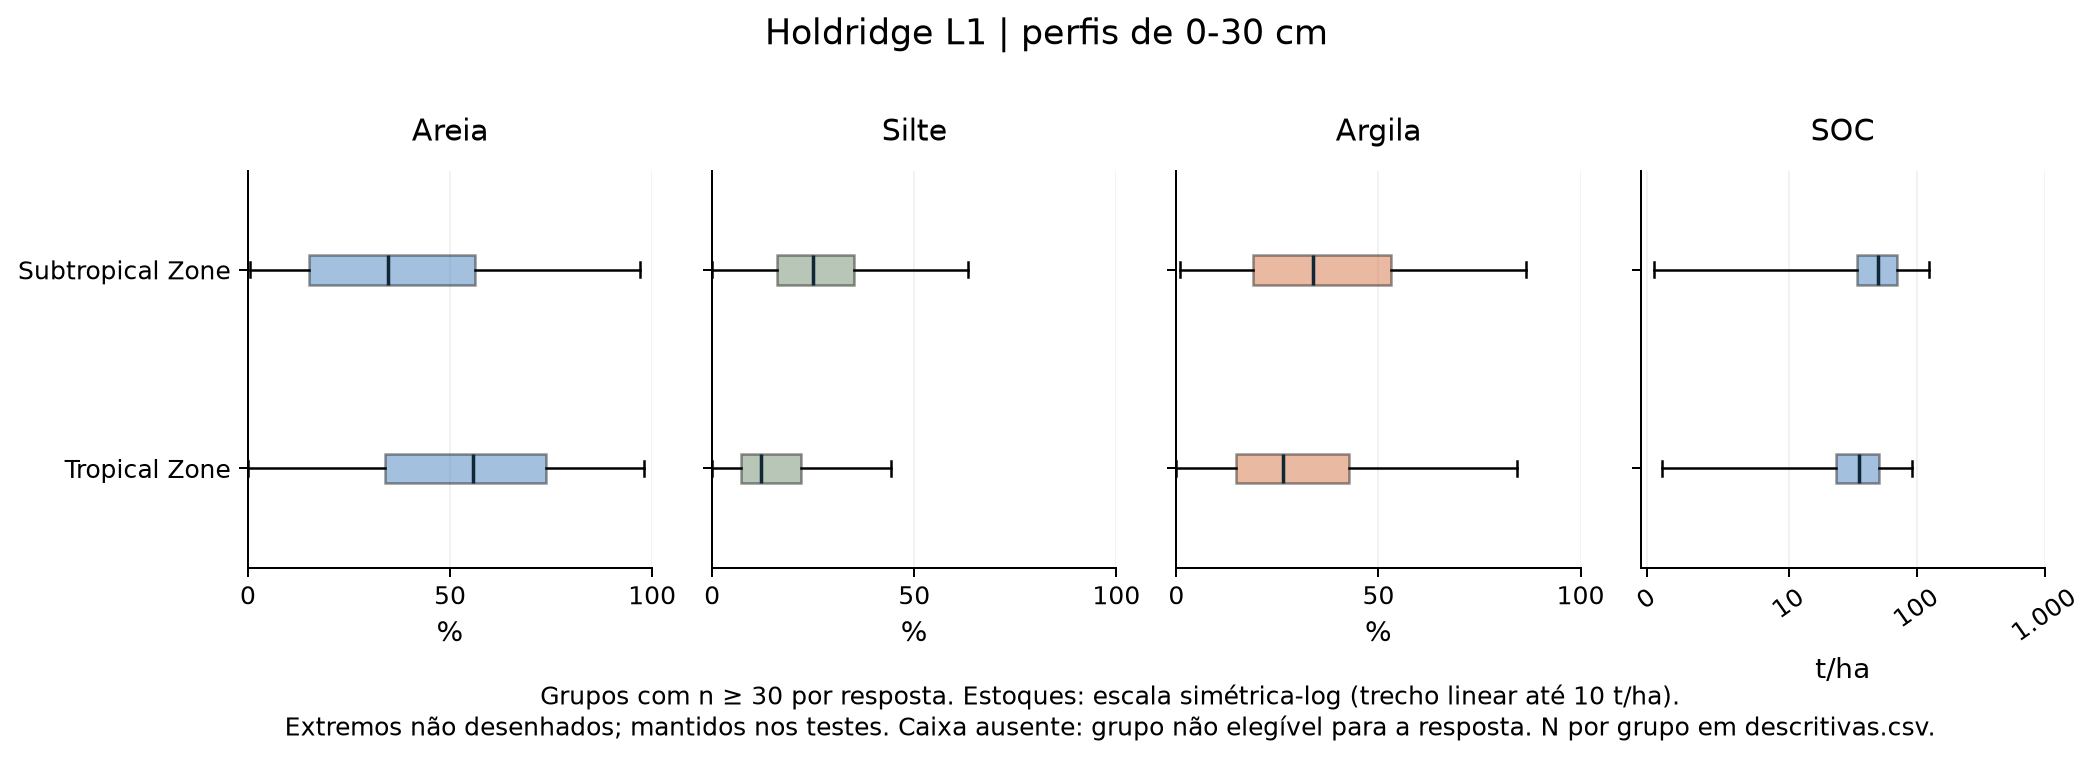

In [17]:
display(Image("resultados/figuras/painel_HLZ_L1.png"))

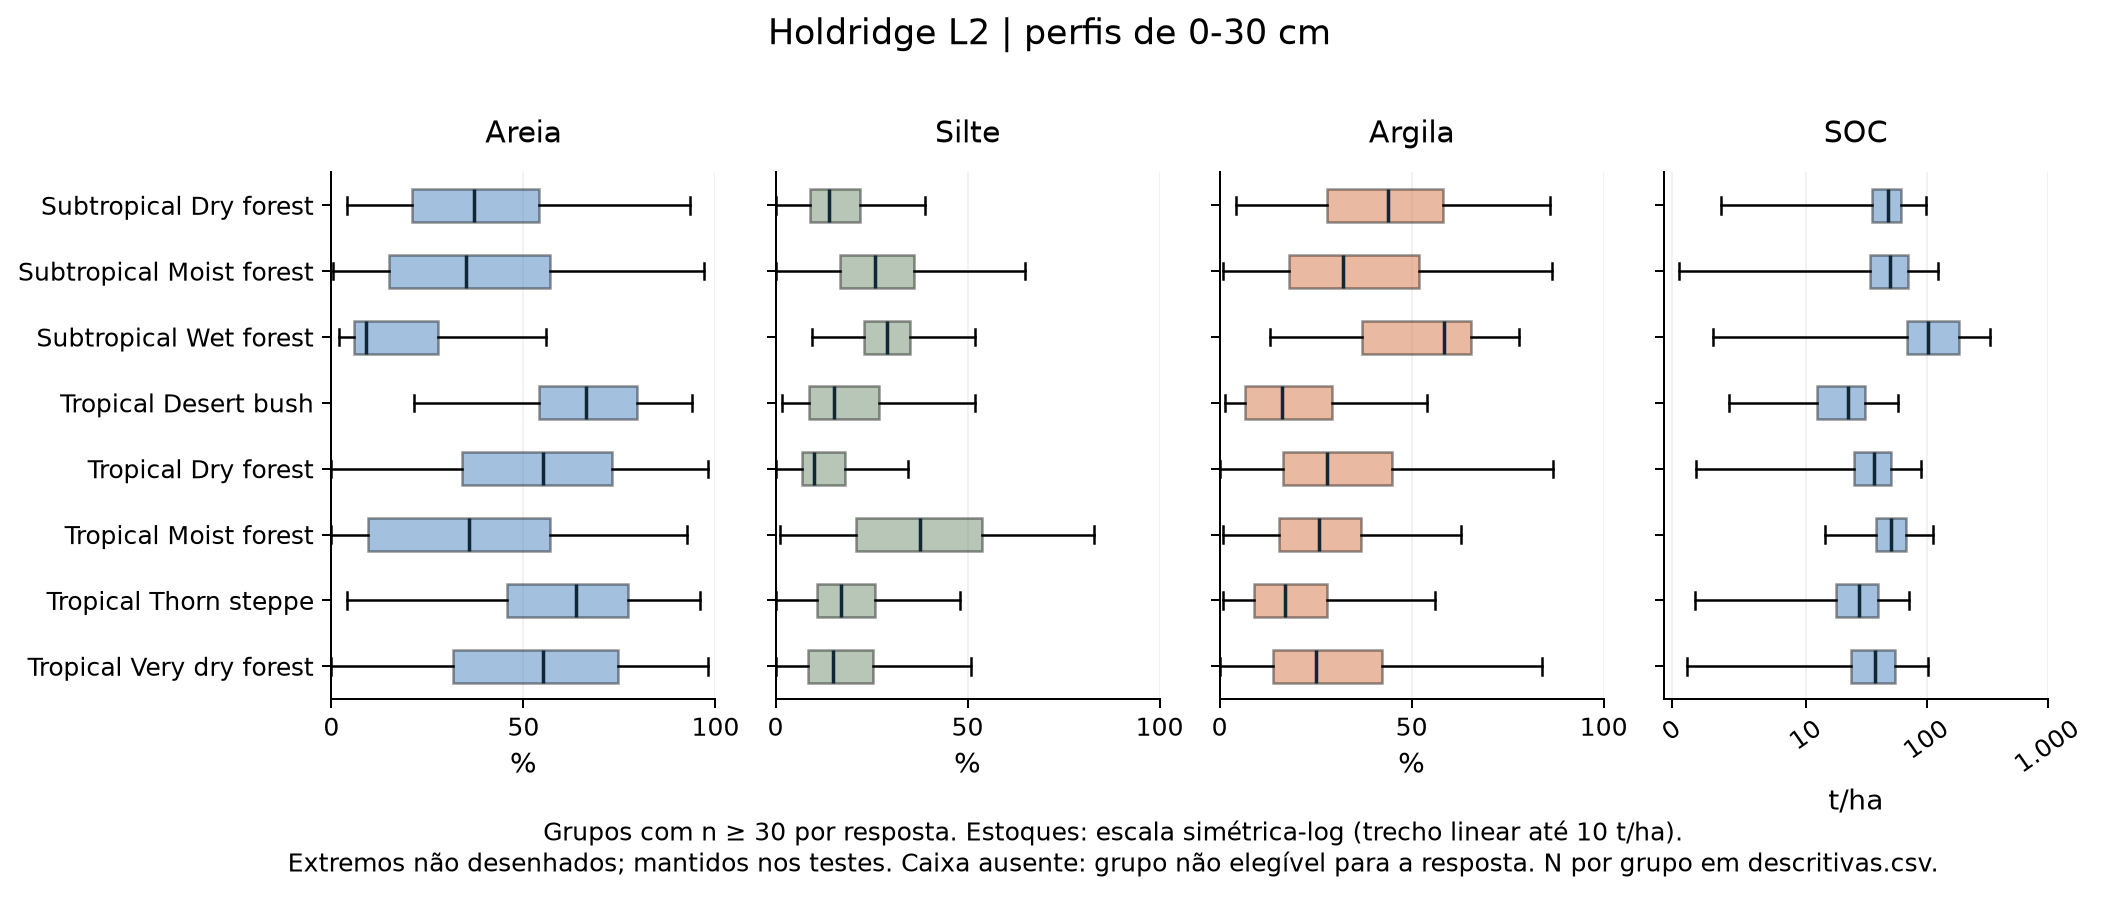

In [18]:
display(Image("resultados/figuras/painel_HLZ_L2.png"))

## Explorar todas as tabelas

Os CSVs abaixo mantêm todas as classes e comparações completas da análise. O pandas pode abreviar a visualização; filtre por `nivel` e `variavel` para examinar um subconjunto.

In [19]:
testes_globais = pd.read_csv(TABELAS / "testes_globais.csv")
testes_globais

,variavel,nivel,n,n_classes,H,p,eta2,epsilon2,F_anova,p_anova,F_welch,p_welch,variavel_pt,p_holm_omnibus
0,areia,koppen_l1,12062,3,1022.465128,9.430147e-223,0.084623,0.084774,564.949896,2.943676e-235,584.721303,3.017120e-152,areia,1.131618e-221
1,silte,koppen_l1,12062,3,1456.042954,0.000000e+00,0.120577,0.120723,579.158937,6.803258e-241,571.546326,1.191669e-149,silte,0.000000e+00
2,argila,koppen_l1,12062,3,396.521309,7.879375e-87,0.032716,0.032876,209.068716,5.512016e-90,274.150792,3.306181e-90,argila,1.575875e-86
3,areia,koppen_l2,12061,7,1134.525586,7.062672e-242,0.093622,0.094073,210.839668,9.903096e-257,220.144042,5.223061e-214,areia,1.059401e-240
4,silte,koppen_l2,12061,7,2245.521333,0.000000e+00,0.185791,0.186196,386.364391,0.000000e+00,370.339621,4.455525e-314,silte,0.000000e+00
5,argila,koppen_l2,12061,7,762.049740,2.433087e-161,0.062722,0.063188,132.063721,1.575475e-162,164.279769,1.868836e-169,argila,1.703161e-160
6,areia,koppen_l3,4353,5,651.006862,1.411055e-139,0.148806,0.149588,192.302204,5.236030e-152,274.038111,3.484690e-163,areia,7.055274e-139
7,silte,koppen_l3,4353,5,489.062244,1.554496e-104,0.111560,0.112376,101.824470,5.362792e-83,115.827173,3.256361e-82,silte,4.663488e-104
8,argila,koppen_l3,4353,5,746.520989,2.939008e-160,0.170773,0.171535,204.452364,6.555994e-161,272.661226,1.955203e-163,argila,1.763405e-159
9,areia,HLZ_L1,12053,2,927.226497,1.183599e-203,0.076859,0.076935,1012.648840,1.880489e-213,1042.151459,1.017452e-213,areia,1.301958e-202


In [20]:
descritivas = pd.read_csv(TABELAS / "descritivas.csv")
descritivas

,classe,n,media,desvio_padrao,mediana,q25,q75,variavel,nivel,unidade
0,A,7708,53.172658,25.138893,55.9,34.30,73.800,areia,koppen_l1,%
1,B,267,62.320225,21.201687,64.7,50.75,78.525,areia,koppen_l1,%
2,C,4087,37.627954,24.667900,35.0,15.00,57.350,areia,koppen_l1,%
3,A,7708,16.509516,13.740092,12.0,7.00,21.700,silte,koppen_l1,%
4,B,267,19.067416,12.430881,16.5,10.00,26.000,silte,koppen_l1,%
...,...,...,...,...,...,...,...,...,...,...
107,Tropical_Desert_bush,44,2645.272727,2040.715246,2220.0,1215.00,3070.000,SOC,HLZ_L2,g/m2
108,Tropical_Dry_forest,4554,4519.326307,5543.303095,3622.0,2479.50,5033.500,SOC,HLZ_L2,g/m2
109,Tropical_Moist_forest,133,5662.691729,3054.247212,5006.0,3760.00,6749.000,SOC,HLZ_L2,g/m2
110,Tropical_Thorn_steppe,873,3005.617411,1739.458506,2739.0,1774.00,3902.000,SOC,HLZ_L2,g/m2


In [21]:
dunn_pares = pd.read_csv(TABELAS / "dunn_pares.csv")
dunn_pares

,variavel,nivel,classe_1,classe_2,p_holm
0,areia,koppen_l1,A,B,1.212222e-08
1,areia,koppen_l1,A,C,4.636096e-206
2,areia,koppen_l1,B,C,1.268772e-50
3,silte,koppen_l1,A,B,3.046899e-06
4,silte,koppen_l1,A,C,0.000000e+00
...,...,...,...,...,...
247,SOC,HLZ_L2,Tropical_Dry_forest,Tropical_Thorn_steppe,3.879618e-36
248,SOC,HLZ_L2,Tropical_Dry_forest,Tropical_Very_dry_forest,4.355649e-01
249,SOC,HLZ_L2,Tropical_Moist_forest,Tropical_Thorn_steppe,6.953955e-30
250,SOC,HLZ_L2,Tropical_Moist_forest,Tropical_Very_dry_forest,1.546459e-09


In [22]:
ponto_bisserial = pd.read_csv(TABELAS / "ponto_bisserial.csv")
ponto_bisserial

,classe,n_classe,n_total,r_pb,p,p_holm,variavel_pt,nivel
0,koppen_l1_C,4087,12062,-0.288149,2.532544e-229,7.597631e-229,areia,koppen_l1
1,koppen_l1_A,7708,12062,0.258810,7.626346e-184,1.525269e-183,areia,koppen_l1
2,koppen_l1_B,267,12062,0.082126,1.655838e-19,1.655838e-19,areia,koppen_l1
3,koppen_l1_C,4087,12062,0.294895,1.366702e-240,4.100106e-240,silte,koppen_l1
4,koppen_l1_A,7708,12062,-0.288789,2.227842e-230,4.455684e-230,silte,koppen_l1
...,...,...,...,...,...,...,...,...
95,HLZ_L2_Subtropical_Moist_forest,3671,12277,0.063076,2.649095e-12,1.324547e-11,SOC,HLZ_L2
96,HLZ_L2_Tropical_Very_dry_forest,2621,12277,0.032839,2.734291e-04,1.093717e-03,SOC,HLZ_L2
97,HLZ_L2_Tropical_Desert_bush,44,12277,-0.022586,1.232590e-02,3.697770e-02,SOC,HLZ_L2
98,HLZ_L2_Tropical_Moist_forest,133,12277,0.008970,3.203273e-01,6.406547e-01,SOC,HLZ_L2


In [23]:
spearman = pd.read_csv(TABELAS / "spearman.csv")
spearman

,par,soc,textura,rho,p,n,p_holm
0,SOC x areia,soc_g_m2,areia,-0.498704,0.0,9792,0.0
1,SOC x silte,soc_g_m2,silte,0.383910,0.0,9792,0.0
2,SOC x argila,soc_g_m2,argila,0.436549,0.0,9792,0.0


In [24]:
cobertura = pd.read_csv(TABELAS / "cobertura.csv")
cobertura

,variavel,nivel,n_base,n_sem_classe,n_teste,n_classes_teste
0,areia,koppen_l1,12062,0,12062,3
1,silte,koppen_l1,12062,0,12062,3
2,argila,koppen_l1,12062,0,12062,3
3,areia,koppen_l2,12062,0,12061,7
4,silte,koppen_l2,12062,0,12061,7
5,argila,koppen_l2,12062,0,12061,7
6,areia,koppen_l3,12062,7708,4353,5
7,silte,koppen_l3,12062,7708,4353,5
8,argila,koppen_l3,12062,7708,4353,5
9,areia,HLZ_L1,12062,9,12053,2


In [25]:
comparacao_mesmos_pontos = pd.read_csv(TABELAS / "comparacao_mesmos_pontos.csv")
comparacao_mesmos_pontos

,variavel,nivel,n,n_classes,H,p,eta2,epsilon2,F_anova,p_anova,F_welch,p_welch,variavel_pt,comparacao_nivel
0,areia,koppen_l1,12053,3,1021.393094,1.611787e-222,0.084597,0.084749,564.329545,5.282448e-235,584.210360,3.635254e-152,areia,1
1,areia,HLZ_L1,12053,2,927.226497,1.183599e-203,0.076859,0.076935,1012.648840,1.880489e-213,1042.151459,1.017452e-213,areia,1
2,areia,koppen_l2,12048,7,1132.947248,1.550578e-241,0.093592,0.094044,210.529497,2.365179e-256,219.881310,1.295467e-213,areia,2
3,areia,HLZ_L2,12048,8,1090.547788,3.254688e-231,0.089996,0.090524,173.280646,2.400694e-245,199.028935,2.605052e-136,areia,2
4,silte,koppen_l1,12053,3,1455.394466,0.000000e+00,0.120614,0.120760,578.519470,1.241856e-240,571.068690,1.418348e-149,silte,1
5,silte,HLZ_L1,12053,2,1582.687986,0.000000e+00,0.131250,0.131322,1325.154799,2.283325e-275,1313.433331,1.687269e-263,silte,1
6,silte,koppen_l2,12048,7,2244.746240,0.000000e+00,0.185927,0.186332,386.164489,0.000000e+00,370.399636,1.018456e-313,silte,2
7,silte,HLZ_L2,12048,8,2161.805416,0.000000e+00,0.178971,0.179448,290.086131,0.000000e+00,268.265788,1.639353e-159,silte,2
8,argila,koppen_l1,12053,3,396.205287,9.228160e-87,0.032714,0.032875,208.866582,6.718572e-90,274.033138,3.522275e-90,argila,1
9,argila,HLZ_L1,12053,2,212.690097,3.556152e-48,0.017566,0.017648,223.944017,3.519093e-50,213.891075,1.067691e-47,argila,1


In [26]:
regressao_modelos = pd.read_csv(TABELAS / "regressao_modelos.csv")
regressao_modelos

,modelo,n,k,R2,R2_aj,AIC,alvo,referencia_clima
0,M1 clima,9791,6,0.085359,0.084798,18504.432430,SOC,Am
1,M2 textura,9791,2,0.224873,0.224715,16875.977041,SOC,Am
2,M3 textura+clima,9791,8,0.248405,0.247790,16586.130169,SOC,Am
3,M4 textura+clima+relevo,9791,10,0.270175,0.269429,16302.336240,SOC,Am
4,M5 clima+relevo,9791,8,0.134988,0.134281,17962.205773,SOC,Am


In [27]:
regressao_coeficientes = pd.read_csv(TABELAS / "regressao_coeficientes.csv")
regressao_coeficientes

,alvo,termo,coef_log,p_HC3,ic95_inf,ic95_sup,variacao_condicional_pct
0,SOC,const,8.532823,0.000000e+00,8.441058,8.624588,507776.365636
1,SOC,areia,-0.010848,2.280640e-109,-0.011805,-0.009891,-1.078969
2,SOC,argila,-0.000995,1.086890e-01,-0.002211,0.000221,-0.099457
3,SOC,koppen_l2_Af,0.172215,4.759011e-07,0.105188,0.239243,18.793371
4,SOC,koppen_l2_As,-0.126700,1.582058e-05,-0.184224,-0.069176,-11.900188
5,SOC,koppen_l2_Aw,-0.048476,1.427935e-02,-0.087254,-0.009698,-4.732007
6,SOC,koppen_l2_Bs,-0.407815,8.400238e-25,-0.485545,-0.330085,-33.489834
7,SOC,koppen_l2_Cf,-0.121935,7.964497e-05,-0.182508,-0.061362,-11.479401
8,SOC,koppen_l2_Cw,-0.165801,2.119031e-08,-0.223809,-0.107792,-15.278488
9,SOC,elevation,0.000367,1.427997e-47,0.000317,0.000416,0.036683


In [28]:
validacao_modelos = pd.read_csv(TABELAS / "validacao_modelos.csv")
validacao_modelos

,alvo,esquema,modelo,n,R2_oof,R2_baseline_oof,RMSE_log_oof
0,SOC,aleatoria,OLS,9791,0.268924,-0.000351,0.556166
1,SOC,aleatoria,RandomForest,9791,0.412126,-0.000351,0.498730
2,SOC,espacial_1grau,OLS,9791,0.247224,-0.007933,0.564360
3,SOC,espacial_1grau,RandomForest,9791,0.285999,-0.007933,0.549632
4,SOC,espacial_2graus,OLS,9791,0.254143,-0.003428,0.561760
5,SOC,espacial_2graus,RandomForest,9791,0.262096,-0.003428,0.558757
6,SOC,espacial_5graus,OLS,9791,0.252225,-0.023828,0.562482
7,SOC,espacial_5graus,RandomForest,9791,0.248025,-0.023828,0.564059


In [29]:
validacao_folds = pd.read_csv(TABELAS / "validacao_folds.csv")
validacao_folds

,alvo,esquema,modelo,fold,n_treino,n_teste,R2,RMSE_log,blocos_treino,blocos_teste
0,SOC,aleatoria,OLS,1,7832,1959,0.267498,0.548031,NaN,NaN
1,SOC,aleatoria,OLS,2,7833,1958,0.265588,0.563434,NaN,NaN
2,SOC,aleatoria,OLS,3,7833,1958,0.271265,0.541794,NaN,NaN
3,SOC,aleatoria,OLS,4,7833,1958,0.269501,0.571775,NaN,NaN
4,SOC,aleatoria,OLS,5,7833,1958,0.268596,0.555285,NaN,NaN
5,SOC,aleatoria,RandomForest,1,7832,1959,0.387133,0.501284,NaN,NaN
6,SOC,aleatoria,RandomForest,2,7833,1958,0.420423,0.500529,NaN,NaN
7,SOC,aleatoria,RandomForest,3,7833,1958,0.416169,0.484945,NaN,NaN
8,SOC,aleatoria,RandomForest,4,7833,1958,0.424328,0.507579,NaN,NaN
9,SOC,aleatoria,RandomForest,5,7833,1958,0.409281,0.499031,NaN,NaN


In [30]:
logistica_validacao = pd.read_csv(TABELAS / "logistica_validacao.csv")
logistica_validacao

,esquema,n,acuracia_oof,acuracia_balanceada_oof,baseline_treino_oof
0,aleatoria,9791,0.477888,0.215845,0.344092
1,espacial_2graus,9791,0.445103,0.200389,0.219385


In [31]:
importancia_climatica = pd.read_csv(TABELAS / "importancia_climatica.csv")
importancia_climatica

,variavel_pt,bloco,queda_r2_media,queda_r2_dp,r2_base_medio,n_folds,queda_pct_do_r2
0,SOC,Holdridge L2,0.023237,0.012240,0.262871,5,8.839877
1,SOC,Köppen L2,0.009868,0.010003,0.262871,5,3.753902
2,SOC,Relevo,0.098311,0.031519,0.262871,5,37.398962
3,SOC,Textura,0.430954,0.066331,0.262871,5,163.941124
4,areia,Holdridge L2,0.077478,0.047842,0.117115,5,66.155611
5,areia,Köppen L2,0.012697,0.028103,0.117115,5,10.841247
6,areia,Relevo,0.474932,0.186130,0.117115,5,405.526412
7,argila,Holdridge L2,0.013246,0.029465,0.107283,5,12.347085
8,argila,Köppen L2,0.038960,0.013141,0.107283,5,36.315388
9,argila,Relevo,0.347962,0.125700,0.107283,5,324.339997


In [32]:
importancia_climatica_folds = pd.read_csv(TABELAS / "importancia_climatica_folds.csv")
importancia_climatica_folds

,variavel_pt,fold,n_teste,r2_base_fold,bloco,queda_r2_media,queda_r2_dp
0,areia,1,2411,-0.025160,Köppen L2,0.041009,0.008481
1,areia,1,2411,-0.025160,Holdridge L2,0.052850,0.006662
2,areia,1,2411,-0.025160,Relevo,0.454031,0.021549
3,areia,2,2411,0.381214,Köppen L2,0.000423,0.001426
4,areia,2,2411,0.381214,Holdridge L2,0.021647,0.004383
...,...,...,...,...,...,...,...
60,SOC,4,1958,0.293820,Textura,0.403831,0.021972
61,SOC,5,1957,0.285349,Köppen L2,0.000177,0.002594
62,SOC,5,1957,0.285349,Holdridge L2,0.041556,0.005700
63,SOC,5,1957,0.285349,Relevo,0.100493,0.010064


### Exemplo de seleção: SOC × Köppen L2

In [33]:
dunn_pares.query("variavel == 'SOC' and nivel == 'koppen_l2'")

,variavel,nivel,classe_1,classe_2,p_holm
192,SOC,koppen_l2,Af,Am,6.110467e-18
193,SOC,koppen_l2,Af,As,2.452988e-23
194,SOC,koppen_l2,Af,Aw,4.773424e-05
195,SOC,koppen_l2,Af,Bs,2.719756e-44
196,SOC,koppen_l2,Af,Cf,2.970727e-02
197,SOC,koppen_l2,Af,Cw,7.839749e-05
198,SOC,koppen_l2,Am,As,1.373100e-04
199,SOC,koppen_l2,Am,Aw,6.117901e-11
200,SOC,koppen_l2,Am,Bs,8.470112e-23
201,SOC,koppen_l2,Am,Cf,1.028789e-115


### Recalcular a análise (opcional)

Esta etapa exige uma conta com acesso liberado às matrizes do Earth Engine (ver `docs/assets.md`) e os passos descritos em `docs/reproducao.md`. Mantém-se desligada por padrão para que o professor possa abrir e executar o caderno sem acesso ao GEE.

In [34]:
RECALCULAR = False
if RECALCULAR:
    import subprocess, sys
    subprocess.run([sys.executable, "codigo/preparar_dados.py"], check=True)
    subprocess.run([sys.executable, "codigo/reproduzir.py"], check=True)
else:
    print("Leitura dos resultados publicados; nenhuma consulta externa realizada.")

Leitura dos resultados publicados; nenhuma consulta externa realizada.
